## Factorization or Feedback? From ADMM to PIPG

The splitQP baseline treats quadratic curvature and constraint coupling
implicitly. For fixed $P$ and $A$, proximal ADMM factors

$$
P+\sigma I+A^\top\operatorname{diag}(\rho_{\mathrm{ADMM}})A
$$

once and applies the same factor through two triangular solves at every
iteration. This allocation is well matched to a family of problems that shares
its matrices: the factorization is an offline cost, while the online iteration
applies the same coupled implicit operator.

PIPG makes a different allocation. It couples a projected primal-gradient step
to a constraint-space feedback state. When the primal and cone projections are
closed form, the online iteration consists of matrix-vector products and
projections, with no linear-system solve. The trade-off is that stability and progress depend more directly on
the geometry of $P$ and the constraint operator, and a projection made difficult by
a change of coordinates can remove the intended advantage.

ADMM and PIPGeq are therefore two computational realizations of constrained
first-order optimization, not successive points in one historical derivation.
The paper lineage considered here is

$$
\mathrm{PIPGeq}\longrightarrow\mathrm{PIPG}
\longrightarrow\mathrm{xPIPG}
\longrightarrow\text{preconditioned xPIPG}.
$$

The question throughout is consequently conditional: when should a solver pay
for a reusable factorization, and when is explicit primal-dual feedback the
more suitable online operation?

#### Organization

Stage 1 isolates the factorization–feedback choice on a geometric QP and then
on a small trajectory QP. Stage 2 replaces equality residuals by product-cone
residuals and records the exact constant-step relation to PDHG. Stage 3 writes
xPIPG as a relaxed fixed-point iteration and examines what its successive
differences can, and cannot, establish about infeasibility. Stage 4 studies
preconditioning as a change in the geometry presented to the iteration, with
explicit attention to setup cost and projection structure.

In [1]:
import math
import os
import time
from functools import partial
from typing import NamedTuple

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import cvxpy as cp
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import splitqp

assert jax.config.x64_enabled
assert "CLARABEL" in cp.installed_solvers()

#### Computational conventions

JAX uses 64-bit arithmetic throughout. CVXPY with Clarabel supplies independent
high-accuracy solutions for objectives, multiplier signs, and feasibility
classification. These reference solutions are evaluated only after an
iterative run; they are not used by a PIPG update or stopping test.

Reported timings distinguish data construction, algorithmic setup, JAX
compilation, and synchronized post-compilation execution. Pedagogical runs
retain complete traces, whereas the timed kernels retain only the state needed
by the iteration.

#### Notation and cone convention

The papers and implementations reuse several letters for different operators.
This notebook keeps one notation across all stages.

| Symbol or name | Meaning |
|---|---|
| $P\in\mathbb S_+^n$ | objective Hessian; the PIPGeq paper denotes it by $H$ |
| $q\in\mathbb R^n$ | objective linear term; the PIPGeq paper denotes it by $h$ |
| $G\in\mathbb R^{m_e\times n}$ | equality operator in $Gz=g$ |
| $H\in\mathbb R^{m\times n}$ | general conic operator in $Hz-g\in K$ |
| $Z$ or $D$ | closed convex primal set; here it is usually a box |
| $K$ | closed convex cone, represented as a Cartesian product of blocks |
| $z$ | PIPG primal variable; splitQP names the corresponding variable `x` |
| $w$ | integral or polar-projected dual-like correction |
| $v$ | PIPGeq PI combination, or the PIPG prediction state |
| $\xi,\eta$ | persistent relaxed states in xPIPG |
| $\alpha,\beta$ | PIPG primal and dual/residual step sizes |
| $\rho$ (`rho_relax`) | xPIPG fixed-point relaxation |
| $\rho_{\mathrm{ADMM}}$ | splitQP diagonal penalty metric, unrelated to `rho_relax` |
| $\alpha_{\mathrm{ADMM}}$ | splitQP relaxation parameter |

The multiplier convention is the polar cone

$$
K^\circ=\{w:\langle w,y\rangle\le 0\ \text{for all }y\in K\}
=-K^*,
$$

where $K^*$ is the usual dual cone. Thus $\mathbb R_+^\circ=\mathbb R_-$,
$\{0\}^\circ=\mathbb R^m$, and the polar of a self-dual second-order cone is
its negative. This sign determines both the projection and the stationarity
term $H^\top w$.

#### Projection primitives

Only the sets required by the experiments are implemented. The SOC convention
places the scalar last: $x=(a,t)\in\mathbb R^{p}\times\mathbb R$. Its Euclidean
projection is

$$
\Pi_{\mathcal Q}(a,t)=
\begin{cases}
(a,t),&\|a\|\le t,\\
0,&\|a\|\le-t,\\
\frac12(1+t/\|a\|)(a,\|a\|),&\text{otherwise}.
\end{cases}
$$

For a closed convex cone, Moreau decomposition gives

$$
y=\Pi_K(y)+\Pi_{K^\circ}(y),\qquad
\langle\Pi_K(y),\Pi_{K^\circ}(y)\rangle=0.
$$

Consequently,

$$
\Pi_{K^\circ}(y)=y-\Pi_K(y),\qquad
\Pi_{\mathcal Q^\circ}(y)=-\Pi_{\mathcal Q}(-y).
$$

Boxes, orthants, zero cones, SOCs, and products of these blocks therefore admit
direct projections here. The later claim of a factorization-free online step is
conditional on retaining this property.

In [2]:
def project_box(x, lower, upper):
    return jnp.clip(x, lower, upper)

def project_zero_cone(x):
    return jnp.zeros_like(x)

def project_zero_cone_polar(x):
    return x

def project_nonnegative_orthant(x):
    return jnp.maximum(x, 0.0)

def project_nonpositive_orthant(x):
    return jnp.minimum(x, 0.0)

def project_soc(x):
    # SOC convention: vector component first, scalar component last.
    a, t = x[:-1], x[-1]
    norm_a = jnp.linalg.norm(a)
    safe_norm = jnp.where(norm_a > 0.0, norm_a, 1.0)
    scale = 0.5 * (1.0 + t / safe_norm)
    middle = jnp.concatenate((scale * a, jnp.array([0.5 * (norm_a + t)])))
    # Select the interior, negative-polar, or boundary branch.
    return jnp.where(
        norm_a <= t, x,
        jnp.where(norm_a <= -t, jnp.zeros_like(x), middle))

def project_soc_polar(x):
    return -project_soc(-x)

def project_product_cone(x, n_zero, n_nonnegative, n_soc):
    # Blocks are ordered as zero, nonnegative orthant, then 3D SOCs.
    parts, cursor = [], 0
    if n_zero:
        parts.append(jnp.zeros_like(x[cursor:cursor + n_zero]))
        cursor += n_zero
    if n_nonnegative:
        parts.append(project_nonnegative_orthant(
            x[cursor:cursor + n_nonnegative]))
        cursor += n_nonnegative
    for _ in range(n_soc):
        parts.append(project_soc(x[cursor:cursor + 3]))
        cursor += 3
    return jnp.concatenate(parts) if parts else x

def project_product_cone_polar(x, n_zero, n_nonnegative, n_soc):
    parts, cursor = [], 0
    if n_zero:
        parts.append(project_zero_cone_polar(x[cursor:cursor + n_zero]))
        cursor += n_zero
    if n_nonnegative:
        parts.append(project_nonpositive_orthant(
            x[cursor:cursor + n_nonnegative]))
        cursor += n_nonnegative
    for _ in range(n_soc):
        parts.append(project_soc_polar(x[cursor:cursor + 3]))
        cursor += 3
    return jnp.concatenate(parts) if parts else x

def distance_to_product_cone(x, n_zero, n_nonnegative, n_soc):
    return jnp.linalg.norm(
        x - project_product_cone(x, n_zero, n_nonnegative, n_soc))

##### Polar-cone sign

Two local checks fix the convention before it enters an iteration. Random
orthant and SOC vectors verify Moreau decomposition, idempotence, and
orthogonality. A scalar constrained quadratic then compares the CVXPY dual
multiplier with the paper variable $w\in K^\circ$; the two have opposite signs
because $K^\circ=-K^*$.

In [3]:
rng = np.random.default_rng(7)
projection_rows = []

for name, proj, proj_polar, member in (
    ("orthant", project_nonnegative_orthant,
     project_nonpositive_orthant, lambda x: np.min(x) >= -1e-12),
    ("SOC", project_soc, project_soc_polar,
     lambda x: np.linalg.norm(x[:-1]) <= x[-1] + 1e-12),
):
    max_moreau = max_idem = max_orth = 0.0
    for _ in range(50):
        x = rng.normal(size=3)
        p = np.asarray(proj(jnp.asarray(x)))
        pp = np.asarray(proj_polar(jnp.asarray(x)))
        max_moreau = max(max_moreau, np.linalg.norm(x - p - pp))
        max_idem = max(max_idem, np.linalg.norm(p - np.asarray(proj(jnp.asarray(p)))))
        max_orth = max(max_orth, abs(float(p @ pp)))
        assert member(p)
    projection_rows.append((name, max_moreau, max_idem, max_orth))

# For 1-z in R_+, the paper multiplier lies in R_- and equals
# the negative of CVXPY's conventional nonnegative multiplier.
z_sign = cp.Variable()
c_sign = z_sign <= 1.0
p_sign = cp.Problem(cp.Minimize(0.5 * cp.square(z_sign - 2.0)), [c_sign])
p_sign.solve(solver="CLARABEL", tol_gap_abs=1e-11, tol_feas=1e-11)
w_paper = -float(c_sign.dual_value)
stationarity = float(z_sign.value - 2.0 - w_paper)
assert w_paper <= 0.0 and abs(stationarity) < 1e-7

print(f"{'cone':<10} {'Moreau':>12} {'idempotence':>14} {'orthogonality':>15}")
for row in projection_rows:
    print(f"{row[0]:<10} {row[1]:>12.2e} {row[2]:>14.2e} {row[3]:>15.2e}")
print(f"CVXPY dual={float(c_sign.dual_value):.6f} | "
      f"polar w={w_paper:.6f} | stationarity={stationarity:.2e}")
assert max(max(r[1:]) for r in projection_rows) < 1e-10

cone             Moreau    idempotence   orthogonality
orthant        0.00e+00       0.00e+00        0.00e+00
SOC            4.44e-16       1.36e-16        4.44e-16
CVXPY dual=1.000000 | polar w=-1.000000 | stationarity=7.71e-13


#### Three related problem instances

The experiments reuse one hierarchy of models rather than introducing a new
problem for each method.

- Problem A has $n=2$ primal variables, one affine equality, and a box. It makes
  the feedback directions visible in the primal plane.
- Problem B is an $N=8$ planar double-integrator QP. Its stacked variable has
  $n=52$ components and its dynamics contribute $32$ equality rows; all state
  and input bounds remain in the primal box.
- Problem C preserves the dynamics and objective of Problem B, fixes the
  terminal state, and appends eight three-dimensional SOC blocks. Hence
  $H\in\mathbb R^{56\times52}$ with a $32$-row zero-cone block and eight
  $\mathcal Q_3$ blocks.

This nesting makes each algorithmic extension answer a specific modeling or
numerical limitation of the preceding experiment.

In [4]:
def make_problem_a():
    P = np.diag([4.0, 1.0])
    q = np.array([-3.0, -1.0])
    G = np.array([[1.0, 1.0]])
    g = np.array([0.5])
    lower, upper = -np.ones(2), np.ones(2)
    z_star = np.array([0.5, 0.0])
    return dict(P=P, q=q, G=G, g=g, lower=lower, upper=upper,
                z_star=z_star)

def make_parallel_problem(epsilon=1e-3):
    P = np.diag([4.0, 1.0])
    center = np.array([0.7, 0.8])
    q = -(P @ center)
    G = np.array([[1.0, 0.0], [1.0, epsilon]])
    z_star = np.array([0.25, -0.25])
    g = G @ z_star
    return dict(P=P, q=q, G=G, g=g,
                lower=-np.ones(2), upper=np.ones(2),
                z_star=z_star, epsilon=epsilon)

def make_mpc_problem(target=(1.0, 0.5), dt=0.25,
                     hard_terminal=False, radius=None):
    N, nx, nu = 8, 4, 2
    target = np.asarray(target, dtype=float)
    Ad = np.array([
        [1.0, 0.0, dt, 0.0],
        [0.0, 1.0, 0.0, dt],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
    ])
    Bd = np.array([
        [0.5 * dt**2, 0.0],
        [0.0, 0.5 * dt**2],
        [dt, 0.0],
        [0.0, dt],
    ])
    n = nx * (N + 1) + nu * N
    state_size = nx * (N + 1)

    # Diagonal tracking objective preserves a cheap box projection.
    weights = []
    Q = np.array([1.0, 1.0, 0.1, 0.1])
    QN = np.array([10.0, 10.0, 1.0, 1.0])
    for k in range(N + 1):
        weights.extend(QN if k == N else Q)
    weights.extend(np.tile(np.array([0.05, 0.05]), N))
    P = np.diag(np.asarray(weights))

    reference = np.zeros(n)
    for k in range(N + 1):
        reference[4 * k:4 * k + 2] = (k / N) * target
    q = -(P @ reference)

    # Multiple-shooting dynamics: x_{k+1} - A_d x_k - B_d u_k = 0.
    G = np.zeros((nx * N, n))
    for k in range(N):
        rows = slice(nx * k, nx * (k + 1))
        xk = slice(nx * k, nx * (k + 1))
        xnext = slice(nx * (k + 1), nx * (k + 2))
        uk = slice(state_size + nu * k, state_size + nu * (k + 1))
        G[rows, xnext] = np.eye(nx)
        G[rows, xk] = -Ad
        G[rows, uk] = -Bd
    g_eq = np.zeros(nx * N)

    # State and control constraints remain in the primal Cartesian box.
    lower, upper = np.empty(n), np.empty(n)
    for k in range(N + 1):
        lower[4 * k:4 * k + 4] = [-1.5, -1.5, -2.0, -2.0]
        upper[4 * k:4 * k + 4] = [1.5, 1.5, 2.0, 2.0]
    lower[:4] = upper[:4] = 0.0
    lower[state_size:] = -1.2
    upper[state_size:] = 1.2
    if hard_terminal:
        terminal = np.array([target[0], target[1], 0.0, 0.0])
        lower[4 * N:4 * (N + 1)] = terminal
        upper[4 * N:4 * (N + 1)] = terminal

    # Append one (u_x, u_y, radius) SOC residual per stage when requested.
    if radius is None:
        H, g = G.copy(), g_eq.copy()
        n_zero, n_soc = G.shape[0], 0
    else:
        H = np.zeros((G.shape[0] + 3 * N, n))
        H[:G.shape[0]] = G
        g = np.zeros(H.shape[0])
        for k in range(N):
            rows = slice(G.shape[0] + 3 * k, G.shape[0] + 3 * (k + 1))
            uk = slice(state_size + 2 * k, state_size + 2 * (k + 1))
            H[rows.start:rows.start + 2, uk] = np.eye(2)
            g[rows.stop - 1] = -float(radius)
        n_zero, n_soc = G.shape[0], N

    return dict(
        N=N, nx=nx, nu=nu, n=n, state_size=state_size,
        Ad=Ad, Bd=Bd, P=P, q=q, G=G, g_eq=g_eq,
        H=H, g=g, lower=lower, upper=upper,
        target=target, dt=dt, radius=radius,
        n_zero=n_zero, n_nonnegative=0, n_soc=n_soc,
    )

def unpack_trajectory(z, problem):
    N = problem["N"]
    states = np.asarray(z[:problem["state_size"]]).reshape(N + 1, 4)
    controls = np.asarray(z[problem["state_size"]:]).reshape(N, 2)
    return states, controls

A = make_problem_a()
B = make_mpc_problem(hard_terminal=False)
C_feas = make_mpc_problem(hard_terminal=True, radius=1.2)
C_infeas = make_mpc_problem(hard_terminal=True, radius=1.0)

assert B["n"] == 52 and B["G"].shape == (32, 52)
assert C_feas["H"].shape == (56, 52)
assert np.allclose(C_feas["H"], C_infeas["H"])

##### Matched feasibility construction

For the conic trajectory, four controls $d=(1,0.5)$ followed by four controls
$-d$ reach terminal position $(1,0.5)$ with zero terminal velocity. Since
$\|d\|=\sqrt{1.25}\approx1.118<1.2$, the radius-$1.2$ instance has an explicit
feasible witness.

The radius-$1.0$ instance changes no other datum. With $\Delta t=0.25$, eight
stages, and zero initial and terminal velocities, its terminal displacement in
any unit direction cannot exceed the control radius; the requested displacement
has norm $\sqrt{1.25}>1$. The construction therefore gives a matched infeasible
instance rather than an unrelated pathological example.

In [5]:
# Construct a feasible witness independently of either iterative solver.
def known_feasible_trajectory(problem):
    N = problem["N"]
    d = np.asarray(problem["target"])
    controls = np.vstack((np.tile(d, (N // 2, 1)),
                          np.tile(-d, (N // 2, 1))))
    states = np.zeros((N + 1, 4))
    for k in range(N):
        states[k + 1] = problem["Ad"] @ states[k] + problem["Bd"] @ controls[k]
    return np.concatenate((states.ravel(), controls.ravel()))

z_known = known_feasible_trajectory(C_feas)
states_known, controls_known = unpack_trajectory(z_known, C_feas)
residual_known = C_feas["H"] @ z_known - C_feas["g"]
known_distance = float(distance_to_product_cone(
    jnp.asarray(residual_known), C_feas["n_zero"], 0, C_feas["n_soc"]))

print(f"terminal={states_known[-1]} | "
      f"max ||u||={np.linalg.norm(controls_known, axis=1).max():.6f} | "
      f"cone distance={known_distance:.1e}")
assert np.allclose(states_known[-1], [1.0, 0.5, 0.0, 0.0])
assert known_distance < 1e-12

residual_tight = C_infeas["H"] @ z_known - C_infeas["g"]
assert float(distance_to_product_cone(
    jnp.asarray(residual_tight), C_infeas["n_zero"], 0,
    C_infeas["n_soc"])) > 0.0

terminal=[1.  0.5 0.  0. ] | max ||u||=1.118034 | cone distance=0.0e+00


#### Reference solutions

Clarabel provides the reference objective values and the feasible/infeasible
classification for the three models. Its iterates do not enter the algorithms
below. This separation allows objective and sign checks without defining
convergence by distance to a known solution.

In [6]:
# Reference solves validate the model; their iterates never enter PIPG.
def solve_equality_reference(problem):
    z = cp.Variable(problem["P"].shape[0])
    constraints = [
        problem["G"] @ z == problem["g_eq"],
        z >= problem["lower"],
        z <= problem["upper"],
    ]
    objective = cp.Minimize(
        0.5 * cp.quad_form(z, problem["P"]) + problem["q"] @ z)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver="CLARABEL", tol_gap_abs=1e-10,
               tol_feas=1e-10, tol_gap_rel=1e-10)
    return dict(status=prob.status, objective=float(prob.value),
                z=np.asarray(z.value), equality_dual=np.asarray(
                    constraints[0].dual_value))

def solve_conic_reference(problem):
    z = cp.Variable(problem["P"].shape[0])
    constraints = [
        problem["G"] @ z == problem["g_eq"],
        z >= problem["lower"],
        z <= problem["upper"],
    ]
    for k in range(problem["N"]):
        ui = problem["state_size"] + 2 * k
        constraints.append(cp.SOC(float(problem["radius"]), z[ui:ui + 2]))
    objective = cp.Minimize(
        0.5 * cp.quad_form(z, problem["P"]) + problem["q"] @ z)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver="CLARABEL", tol_gap_abs=1e-9,
               tol_feas=1e-9, tol_gap_rel=1e-9)
    value = None if z.value is None else np.asarray(z.value)
    return dict(status=prob.status, objective=prob.value, z=value)

A_ref = solve_equality_reference(dict(
    P=A["P"], q=A["q"], G=A["G"], g_eq=A["g"],
    lower=A["lower"], upper=A["upper"]))
B_ref = solve_equality_reference(B)
C_feas_ref = solve_conic_reference(C_feas)
C_infeas_ref = solve_conic_reference(C_infeas)

print(f"A: {A_ref['status']:<11} objective {A_ref['objective']:.9f}")
print(f"B: {B_ref['status']:<11} objective {B_ref['objective']:.9f}")
print(f"C radius 1.2: {C_feas_ref['status']:<11} "
      f"objective {C_feas_ref['objective']:.9f}")
print(f"C radius 1.0: {C_infeas_ref['status']}")
assert np.linalg.norm(A_ref["z"] - A["z_star"]) < 1e-7
assert C_feas_ref["status"] == "optimal"
assert C_infeas_ref["status"].startswith("infeasible")

A: optimal     objective -1.000000000
B: optimal     objective -7.318314618
C radius 1.2: optimal     objective -7.213404405
C radius 1.0: infeasible


#### Residuals in physical coordinates

For $Hz-g\in K$, $z\in D$, and $w\in K^\circ$, the common diagnostics are

$$
r_{\mathrm{pri}}=
\frac{\operatorname{dist}(Hz-g,K)}
{1+\|g\|+\|Hz\|},
$$

$$
r_{\mathrm{stat}}=
\frac{\|z-\Pi_D(z-(Pz+q+H^\top w))\|}
{1+\|q\|+\|Pz\|+\|H^\top w\|},
$$

$$
r_{\mathrm{cone}}=
\frac{\|w-\Pi_{K^\circ}(w+Hz-g)\|}
{1+\|w\|+\|Hz-g\|}.
$$

The second residual is the projected form of
$-(Pz+q+H^\top w)\in N_D(z)$; the third is equivalent to
$Hz-g\in N_{K^\circ}(w)$. Thus the three quantities test primal feasibility and
the two normal-cone relations of the KKT system without requiring an explicit
normal-cone oracle.

Every transformed iterate and multiplier is returned to the original
coordinates before these residuals are evaluated. Reference-solution error is
never a stopping condition.

In [7]:
@partial(jax.jit, static_argnames=("n_zero", "n_nonnegative", "n_soc"))
def conic_diagnostics_one(P, q, H, g, lower, upper, z, w,
                          n_zero, n_nonnegative, n_soc):
    # Primal distance to the product cone.
    Hz = H @ z
    residual = Hz - g
    primal = distance_to_product_cone(
        residual, n_zero, n_nonnegative, n_soc)
    primal = primal / (1.0 + jnp.linalg.norm(g) + jnp.linalg.norm(Hz))

    # Projected stationarity avoids an explicit normal-cone oracle.
    Pz, Htw = P @ z, H.T @ w
    stationarity = jnp.linalg.norm(
        z - project_box(z - (Pz + q + Htw), lower, upper))
    stationarity = stationarity / (
        1.0 + jnp.linalg.norm(q) + jnp.linalg.norm(Pz)
        + jnp.linalg.norm(Htw))

    # Polar fixed point encodes cone feasibility and complementarity.
    projected_w = project_product_cone_polar(
        w + residual, n_zero, n_nonnegative, n_soc)
    cone = jnp.linalg.norm(w - projected_w)
    cone = cone / (
        1.0 + jnp.linalg.norm(w) + jnp.linalg.norm(residual))
    objective = 0.5 * z @ Pz + q @ z
    return jnp.array([objective, primal, stationarity, cone])

def trace_diagnostics(P, q, H, g, lower, upper, zs, ws,
                      n_zero, n_nonnegative=0, n_soc=0):
    fn = jax.vmap(lambda z, w: conic_diagnostics_one(
        jnp.asarray(P), jnp.asarray(q), jnp.asarray(H), jnp.asarray(g),
        jnp.asarray(lower), jnp.asarray(upper), z, w,
        n_zero, n_nonnegative, n_soc))
    return np.asarray(fn(jnp.asarray(zs), jnp.asarray(ws)))

def first_below(diagnostics, tolerance=1e-6):
    kkt = np.max(diagnostics[:, 1:], axis=1)
    indices = np.flatnonzero(kkt <= tolerance)
    return None if not indices.size else int(indices[0])

def sparse_log(name, diagnostics, iterations=(0, 1, 2, 5, 10, 50, 200, 1000)):
    print(f"\n{name}")
    print(f"{'iter':>7} {'objective':>13} {'primal':>11} "
          f"{'stationarity':>13} {'cone':>11}")
    last = len(diagnostics) - 1
    for k in sorted(set(i for i in iterations if i <= last) | {last}):
        d = diagnostics[k]
        print(f"{k:>7} {d[0]:>13.6f} {d[1]:>11.2e} "
              f"{d[2]:>13.2e} {d[3]:>11.2e}")

### Stage 1 — Implicit solve or explicit feedback?

Consider

$$
\begin{aligned}
\min_{z\in[-1,1]^2}\quad &
\tfrac12 z^\top
\begin{bmatrix}4&0\\0&1\end{bmatrix}z
+\begin{bmatrix}-3&-1\end{bmatrix}z,\\
\text{s.t.}\quad &[1,1]z=0.5.
\end{aligned}
$$

The unique solution is $z^\star=(0.5,0)$ with $f^\star=-1$. The box projection
is elementary, but it does not communicate the affine residual to the objective
step. This small problem isolates the distinction between an implicit treatment
of that coupling and an explicit feedback treatment.

#### Projected gradient without equality feedback

Ignoring the equality gives

$$
z^{k+1}=\Pi_Z[z^k-\alpha(Pz^k+q)].
$$

This map has access to the objective and the box only. It can converge as a
box-constrained method while $\|Gz^k-g\|$ remains bounded away from zero. The
experiment establishes the missing quantity that both ADMM and PIPGeq must
return to the primal step.

In [8]:
# Deliberately omit G: this map cannot observe the equality residual.
def projected_gradient_step(P, q, lower, upper, alpha, z):
    return project_box(z - alpha * (P @ z + q), lower, upper)

z_pg = jnp.zeros(2)
pg_trace = [np.asarray(z_pg)]
for _ in range(100):
    z_pg = projected_gradient_step(
        jnp.asarray(A["P"]), jnp.asarray(A["q"]),
        jnp.asarray(A["lower"]), jnp.asarray(A["upper"]), 0.24, z_pg)
    pg_trace.append(np.asarray(z_pg))
pg_trace = np.asarray(pg_trace)
pg_w = np.zeros((len(pg_trace), 1))
pg_diag = trace_diagnostics(
    A["P"], A["q"], A["G"], A["g"], A["lower"], A["upper"],
    pg_trace, pg_w, n_zero=1)
sparse_log("projected gradient (equality deliberately absent)", pg_diag,
           iterations=(0, 1, 2, 5, 20, 100))


projected gradient (equality deliberately absent)
   iter     objective      primal  stationarity        cone
      0      0.000000    3.33e-01      3.40e-01    3.33e-01
      1     -1.334400    1.87e-01      1.09e-01    3.15e-01
      2     -1.458186    2.51e-01      8.04e-02    4.02e-01
      5     -1.592856    3.33e-01      3.50e-02    4.99e-01
     20     -1.624991    3.84e-01      5.64e-04    5.55e-01
    100     -1.625000    3.85e-01      1.65e-13    5.56e-01


#### The implicit branch: splitQP ADMM

Let $s=Ax$ and $R=\operatorname{diag}(\rho_{\mathrm{ADMM}})$. The proximal
splitQP primal update is

$$
\widetilde x^{k+1}=
(P+\sigma I+A^\top R A)^{-1}
[\sigma x^k-q+A^\top(Rs^k-y^k)].
$$

The factorization of the coefficient matrix is reused. An online iteration
applies $A^\top$ and $A$, performs one interval projection for $s$, and uses one
forward and one backward triangular solve. Constraint coupling enters the
primal variable through the inverse operator rather than through a separate
explicit correction.

For Problem A, equality and box rows are combined as

$$
A_{\mathrm{split}}=\begin{bmatrix}G\\I\end{bmatrix},\qquad
l=(g,-1,-1),\quad u=(g,1,1).
$$

In [9]:
from splitqp.solver import State as ADMMState, step as splitqp_step

# Encode the equality and box as splitQP interval rows.
A_split = np.vstack((A["G"], np.eye(2)))
l_split = np.concatenate((A["g"], A["lower"]))
u_split = np.concatenate((A["g"], A["upper"]))
admm_solver_A = splitqp.Solver(A["P"], A_split)
admm_public_A = admm_solver_A.solve(A["q"], l_split, u_split,
                                   eps_abs=1e-9, eps_rel=1e-9,
                                   max_iter=4000)

# Trace the package's unchanged step with its cached factor.
@partial(jax.jit, static_argnames=("steps",))
def trace_splitqp(cache, q, lower, upper, state0, steps):
    def body(state, _):
        state = splitqp_step(cache, q, lower, upper, state)
        return state, state
    return jax.lax.scan(body, state0, None, length=steps)

admm_state0 = ADMMState(jnp.zeros(2), jnp.zeros(3), jnp.zeros(3))
_, admm_trace_state = trace_splitqp(
    admm_solver_A.cache, jnp.asarray(A["q"]),
    jnp.asarray(l_split), jnp.asarray(u_split), admm_state0, steps=120)
admm_zs = np.vstack((np.zeros((1, 2)), np.asarray(admm_trace_state.x)))
admm_weq = np.concatenate((
    np.zeros((1, 1)), np.asarray(admm_trace_state.y[:, :1])), axis=0)
admm_diag = trace_diagnostics(
    A["P"], A["q"], A["G"], A["g"], A["lower"], A["upper"],
    admm_zs, admm_weq, n_zero=1)

adapter_error = np.linalg.norm(
    np.asarray(admm_public_A.x) - admm_zs[-1])
assert admm_solver_A.factorizations == 1
assert adapter_error < 1e-7
assert np.linalg.norm(np.asarray(admm_public_A.x) - A["z_star"]) < 1e-7
print(f"factorizations={admm_solver_A.factorizations} | "
      f"iterations={int(admm_public_A.iterations)}")
sparse_log("splitQP ADMM", admm_diag,
           iterations=(0, 1, 2, 5, 10, 25, 60, 120))

factorizations=1 | iterations=104

splitQP ADMM
   iter     objective      primal  stationarity        cone
      0      0.000000    3.33e-01      3.40e-01    3.33e-01
      1     -1.332064    4.81e-01      1.87e-01    6.10e-01
      2     -1.250223    1.48e-01      9.74e-02    2.07e-01
      5     -1.447360    2.27e-01      2.77e-02    2.64e-01
     10     -1.152724    7.55e-02      1.96e-03    8.06e-02
     25     -1.008884    4.44e-03      1.29e-05    4.45e-03
     60     -1.000009    4.38e-06      1.21e-08    4.38e-06
    120     -1.000000    3.07e-11      8.44e-14    3.07e-11


#### The explicit branch: PIPGeq

PIPGeq exposes the coupling in three updates:

$$
v^k=w^k+\beta(Gz^k-g),
$$

$$
z^{k+1}=
\Pi_Z[z^k-\alpha(Pz^k+q+G^\top v^k)],
$$

$$
w^{k+1}=w^k+\beta(Gz^{k+1}-g).
$$

For constant $\beta$,

$$
w^k=w^0+\beta\sum_{i=1}^k(Gz^i-g).
$$

Hence $w^k$ is the accumulated residual and
$\beta(Gz^k-g)$ is the instantaneous proportional term. The temporary state
$v^k$ is their PI combination, not an additional independent multiplier.
Finally, $G^\top v^k$ maps the constraint-space signal into primal space. This
transpose feedback is the explicit counterpart of the coupling embedded in the
ADMM linear solve.

In [10]:
class PIPGeqData(NamedTuple):
    P: jax.Array
    q: jax.Array
    G: jax.Array
    g: jax.Array
    lower: jax.Array
    upper: jax.Array
    alpha: jax.Array
    beta: jax.Array

class PIPGeqState(NamedTuple):
    z: jax.Array
    w: jax.Array
    residual: jax.Array

def pipgeq_step(data, state):
    # Accumulated residual plus the current proportional signal.
    v = state.w + data.beta * state.residual  # 2009.06980, eqn: pd proportional
    # Map PI feedback back into primal space.
    feedback = data.G.T @ v
    gradient = data.P @ state.z + data.q + feedback
    z_new = project_box(
        state.z - data.alpha * gradient, data.lower, data.upper)
    # Integrate the residual at the new primal point.
    residual_new = data.G @ z_new - data.g
    w_new = state.w + data.beta * residual_new
    return PIPGeqState(z_new, w_new, residual_new)

@partial(jax.jit, static_argnames=("steps",))
def run_pipgeq(data, state0, steps):
    def body(state, _):
        state = pipgeq_step(data, state)
        return state, state
    return jax.lax.scan(body, state0, None, length=steps)

# Constant-step relation from 2009.06980: alpha(lambda + beta sigma) = 1.
def pipgeq_parameters(P, G, beta=None):
    lam = float(np.linalg.eigvalsh(P).max())
    sigma = float(np.linalg.norm(G, 2) ** 2)
    beta = math.sqrt(lam / sigma) if beta is None else float(beta)
    alpha = 1.0 / (lam + sigma * beta)
    return alpha, beta, lam, sigma

alpha_A, beta_A, lambda_A, sigma_A = pipgeq_parameters(A["P"], A["G"])
data_A_eq = PIPGeqData(
    *map(jnp.asarray, (A["P"], A["q"], A["G"], A["g"],
                       A["lower"], A["upper"])),
    jnp.asarray(alpha_A), jnp.asarray(beta_A))
z0_A = jnp.zeros(2)
state0_A_eq = PIPGeqState(
    z0_A, jnp.zeros(1), data_A_eq.G @ z0_A - data_A_eq.g)
_, pipgeq_trace_A = run_pipgeq(data_A_eq, state0_A_eq, steps=500)
pipgeq_zs_A = np.vstack((np.asarray(z0_A)[None], np.asarray(pipgeq_trace_A.z)))
pipgeq_ws_A = np.vstack((np.zeros((1, 1)), np.asarray(pipgeq_trace_A.w)))
pipgeq_diag_A = trace_diagnostics(
    A["P"], A["q"], A["G"], A["g"], A["lower"], A["upper"],
    pipgeq_zs_A, pipgeq_ws_A, n_zero=1)

print(f"lambda={lambda_A:.6g}, sigma=||G||^2={sigma_A:.6g}, "
      f"alpha={alpha_A:.6g}, beta={beta_A:.6g}")
print("alpha(lambda + sigma beta) =",
      alpha_A * (lambda_A + sigma_A * beta_A))
sparse_log("PIPGeq", pipgeq_diag_A,
           iterations=(0, 1, 2, 5, 10, 25, 100, 500))

lambda=4, sigma=||G||^2=2, alpha=0.146447, beta=1.41421
alpha(lambda + sigma beta) = 1.0

PIPGeq
   iter     objective      primal  stationarity        cone
      0      0.000000    3.33e-01      3.40e-01    3.33e-01
      1     -1.257964    1.28e-01      7.69e-02    1.72e-01
      2     -1.249284    1.23e-01      7.10e-03    1.34e-01
      5     -1.002847    4.88e-03      2.80e-02    4.56e-03
     10     -0.988157    5.90e-03      2.14e-03    5.78e-03
     25     -0.999998    8.54e-07      4.63e-06    8.54e-07
    100     -1.000000    0.00e+00      2.07e-17    0.00e+00
    500     -1.000000    5.55e-17      1.47e-17    0.00e+00


##### One PI step in primal space

Before the box projection, one PIPGeq step is the sum of three directions:

$$
-\alpha(Pz+q),\qquad
-\alpha G^\top\beta(Gz-g),\qquad
-\alpha G^\top w.
$$

They are respectively the objective, proportional, and integral contributions.
The figure evaluates all three at the same iterate. Their vector sum is the
unprojected step; clipping onto $Z$ may alter the realized displacement.

In [11]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.facecolor": "#F7F7F5",
    "figure.facecolor": "#F7F7F5",
    "savefig.facecolor": "#F7F7F5",
    "text.color": "#2F3437",
    "axes.edgecolor": "#D9D9D6",
    "axes.labelcolor": "#2F3437",
    "xtick.color": "#2F3437",
    "ytick.color": "#2F3437",
})

def finish_axes(axes, grid_color):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(True, color=grid_color, lw=0.7, alpha=0.75)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

def block(value):
    return jax.block_until_ready(value)

def timed(fn, repeats=5):
    block(fn())  # Compile before measuring synchronized online execution.
    samples = []
    out = None
    for _ in range(repeats):
        t0 = time.perf_counter_ns()
        out = fn()
        block(out)
        samples.append((time.perf_counter_ns() - t0) / 1e6)
    return out, float(np.median(samples)), (
        float(np.percentile(samples, 25)),
        float(np.percentile(samples, 75)),
    )

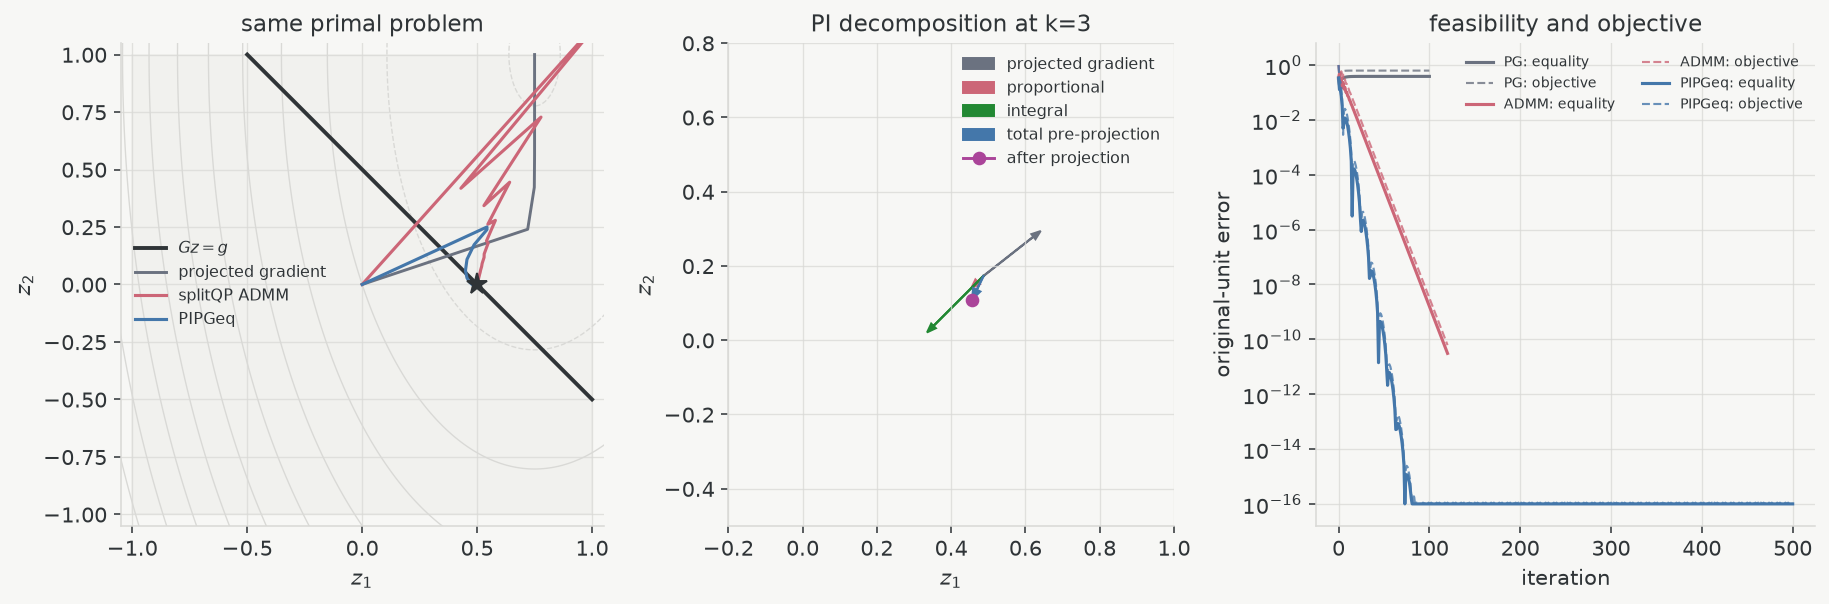

In [12]:
blue, orange, green, purple, gray, dark, grid = (
    "#4477AA", "#CC6677", "#228833", "#AA4499",
    "#6B7280", "#2F3437", "#D9D9D6")

# Evaluate all feedback components at one common iterate.
k_arrow = 3
z_arrow = pipgeq_zs_A[k_arrow]
w_arrow = pipgeq_ws_A[k_arrow]
r_arrow = A["G"] @ z_arrow - A["g"]
d_pg = -alpha_A * (A["P"] @ z_arrow + A["q"])
d_prop = -alpha_A * (A["G"].T @ (beta_A * r_arrow))
d_int = -alpha_A * (A["G"].T @ w_arrow)
trial = z_arrow + d_pg + d_prop + d_int
projected = np.clip(trial, A["lower"], A["upper"])

assert np.allclose(
    projected, pipgeq_zs_A[k_arrow + 1], atol=1e-12)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), dpi=140,
                         layout="constrained")
ax = axes[0]
gx, gy = np.meshgrid(np.linspace(-1.1, 1.1, 240),
                     np.linspace(-1.1, 1.1, 240))
values = (2.0 * gx**2 + 0.5 * gy**2 - 3.0 * gx - gy)
ax.contour(gx, gy, values, levels=14, colors=grid, linewidths=0.7)
ax.fill([-1, 1, 1, -1], [-1, -1, 1, 1], color=grid, alpha=0.2)
line_x = np.linspace(-0.5, 1.0, 100)
ax.plot(line_x, 0.5 - line_x, color=dark, lw=2, label=r"$Gz=g$")
ax.plot(pg_trace[:, 0], pg_trace[:, 1], color=gray, lw=1.5,
        label="projected gradient")
ax.plot(admm_zs[:, 0], admm_zs[:, 1], color=orange, lw=1.6,
        label="splitQP ADMM")
ax.plot(pipgeq_zs_A[:, 0], pipgeq_zs_A[:, 1], color=blue, lw=1.6,
        label="PIPGeq")
ax.plot(*A["z_star"], marker="*", ms=11, color=dark, ls="none")
ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05),
       xlabel=r"$z_1$", ylabel=r"$z_2$", title="same primal problem")
ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=8)

# Decompose the step into objective, proportional, and integral terms.
ax = axes[1]
colors = (gray, orange, green)
labels = ("projected gradient", "proportional", "integral")
for direction, color, label in zip((d_pg, d_prop, d_int), colors, labels):
    ax.arrow(z_arrow[0], z_arrow[1], direction[0], direction[1],
             width=0.0012, head_width=0.018, head_length=0.025,
             length_includes_head=True,
             color=color, label=label)
total = d_pg + d_prop + d_int
ax.arrow(z_arrow[0], z_arrow[1], total[0], total[1],
         width=0.0015, head_width=0.022, head_length=0.030,
         length_includes_head=True,
         color=blue, label="total pre-projection")
ax.plot(*projected, marker="o", color=purple, label="after projection")
ax.set(xlim=(-0.2, 1.0), ylim=(-0.5, 0.8),
       xlabel=r"$z_1$", ylabel=r"$z_2$",
       title=f"PI decomposition at k={k_arrow}")
ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for name, diag, color in (
    ("PG", pg_diag, gray),
    ("ADMM", admm_diag, orange),
    ("PIPGeq", pipgeq_diag_A, blue),
):
    ax.semilogy(np.maximum(diag[:, 1], 1e-16), color=color, lw=1.6,
                label=f"{name}: equality")
    objective_error = np.abs(diag[:, 0] + 1.0)
    ax.semilogy(np.maximum(objective_error, 1e-16), color=color,
                ls="--", lw=1.1, alpha=0.8, label=f"{name}: objective")
ax.set(xlabel="iteration", ylabel="original-unit error",
       title="feasibility and objective")
ax.legend(frameon=False, fontsize=7, ncol=2)
finish_axes(axes, grid)
plt.show()

**Observation.** Projected gradient reaches the optimum of the wrong
problem: its equality residual does not vanish. ADMM and PIPGeq instead approach
the same constrained solution through different online operators. ADMM embeds
curvature and coupling in a cached factor, whereas cached-residual PIPGeq uses
one product each with $P$, $G$, and $G^\top$, followed by a box projection. The
explicit map consequently exposes its progress more directly to the spectrum
and scaling of these operators.

#### The same distinction on a trajectory QP

Problem B has $52$ primal components, $32$ dynamics equalities, and a Cartesian
state/control box. PIPGeq keeps the dynamics in $Gz=g$ and projects the box in
primal space. splitQP represents the same constraints by

$$
A_{\mathrm{split}}=
\begin{bmatrix}G_{\mathrm{dyn}}\\I_{52}\end{bmatrix}
\in\mathbb R^{84\times52}
$$

and reuses one factorization. The larger model tests whether the geometric
distinction persists when $G^\top$ distributes residual feedback through a
dynamical system rather than through one affine line.

In [13]:
# Apply both methods to the same dynamics and primal box.
A_B_split = np.vstack((B["G"], np.eye(B["n"])))
l_B_split = np.concatenate((B["g_eq"], B["lower"]))
u_B_split = np.concatenate((B["g_eq"], B["upper"]))
solver_B = splitqp.Solver(B["P"], A_B_split)
result_B = solver_B.solve(B["q"], l_B_split, u_B_split,
                          eps_abs=1e-7, eps_rel=1e-7, max_iter=10000)

alpha_B, beta_B, lambda_B, sigma_B = pipgeq_parameters(B["P"], B["G"])
data_B_eq = PIPGeqData(
    *map(jnp.asarray, (B["P"], B["q"], B["G"], B["g_eq"],
                       B["lower"], B["upper"])),
    jnp.asarray(alpha_B), jnp.asarray(beta_B))
z0_B = project_box(jnp.zeros(B["n"]), data_B_eq.lower, data_B_eq.upper)
state0_B_eq = PIPGeqState(
    z0_B, jnp.zeros(B["G"].shape[0]), data_B_eq.G @ z0_B - data_B_eq.g)
_, pipgeq_trace_B = run_pipgeq(data_B_eq, state0_B_eq, steps=4000)
pipgeq_zs_B = np.vstack((np.asarray(z0_B)[None], np.asarray(pipgeq_trace_B.z)))
pipgeq_ws_B = np.vstack((
    np.zeros((1, B["G"].shape[0])), np.asarray(pipgeq_trace_B.w)))
pipgeq_diag_B = trace_diagnostics(
    B["P"], B["q"], B["G"], B["g_eq"], B["lower"], B["upper"],
    pipgeq_zs_B, pipgeq_ws_B, n_zero=B["G"].shape[0])

w_admm_eq_B = np.asarray(result_B.y[:B["G"].shape[0]])
diag_admm_B = np.asarray(conic_diagnostics_one(
    *map(jnp.asarray, (B["P"], B["q"], B["G"], B["g_eq"],
                       B["lower"], B["upper"], result_B.x, w_admm_eq_B)),
    n_zero=B["G"].shape[0], n_nonnegative=0, n_soc=0))
k_B = first_below(pipgeq_diag_B, 1e-6)

print(f"PIPGeq lambda={lambda_B:.4g}, sigma={sigma_B:.4g}, "
      f"alpha={alpha_B:.4g}, beta={beta_B:.4g}")
print("splitQP:", result_B.status, "iterations", int(result_B.iterations),
      "factorizations", solver_B.factorizations,
      "common KKT", np.max(diag_admm_B[1:]))
print("PIPGeq first common KKT <= 1e-6:", k_B)
print("CVXPY objective:", B_ref["objective"],
      "splitQP objective:", float(result_B.objective),
      "PIPGeq objective:", pipgeq_diag_B[-1, 0])
sparse_log("PIPGeq trajectory trace", pipgeq_diag_B,
           iterations=(0, 1, 2, 10, 50, 200, 1000, 4000))

PIPGeq lambda=10, sigma=4.439, alpha=0.06001, beta=1.501
splitQP: solved iterations 952 factorizations 1 common KKT 3.0986781707450547e-07
PIPGeq first common KKT <= 1e-6: 1838
CVXPY objective: -7.3183146180273635 splitQP objective: -7.318315252727603 PIPGeq objective: -7.318314618096948

PIPGeq trajectory trace
   iter     objective      primal  stationarity        cone
      0      0.000000    0.00e+00      2.19e-01    0.00e+00
      1     -5.409877    3.80e-01      1.27e-01    2.42e-01
      2     -6.220126    3.81e-01      1.01e-01    1.78e-01
     10     -7.138602    2.46e-01      7.41e-02    5.38e-02
     50     -6.786057    1.24e-01      3.00e-02    1.51e-02
    200     -7.258479    2.84e-02      2.71e-03    9.04e-03
   1000     -7.318309    3.02e-06      1.54e-05    1.13e-06
   4000     -7.318315    5.56e-11      9.01e-10    2.07e-11


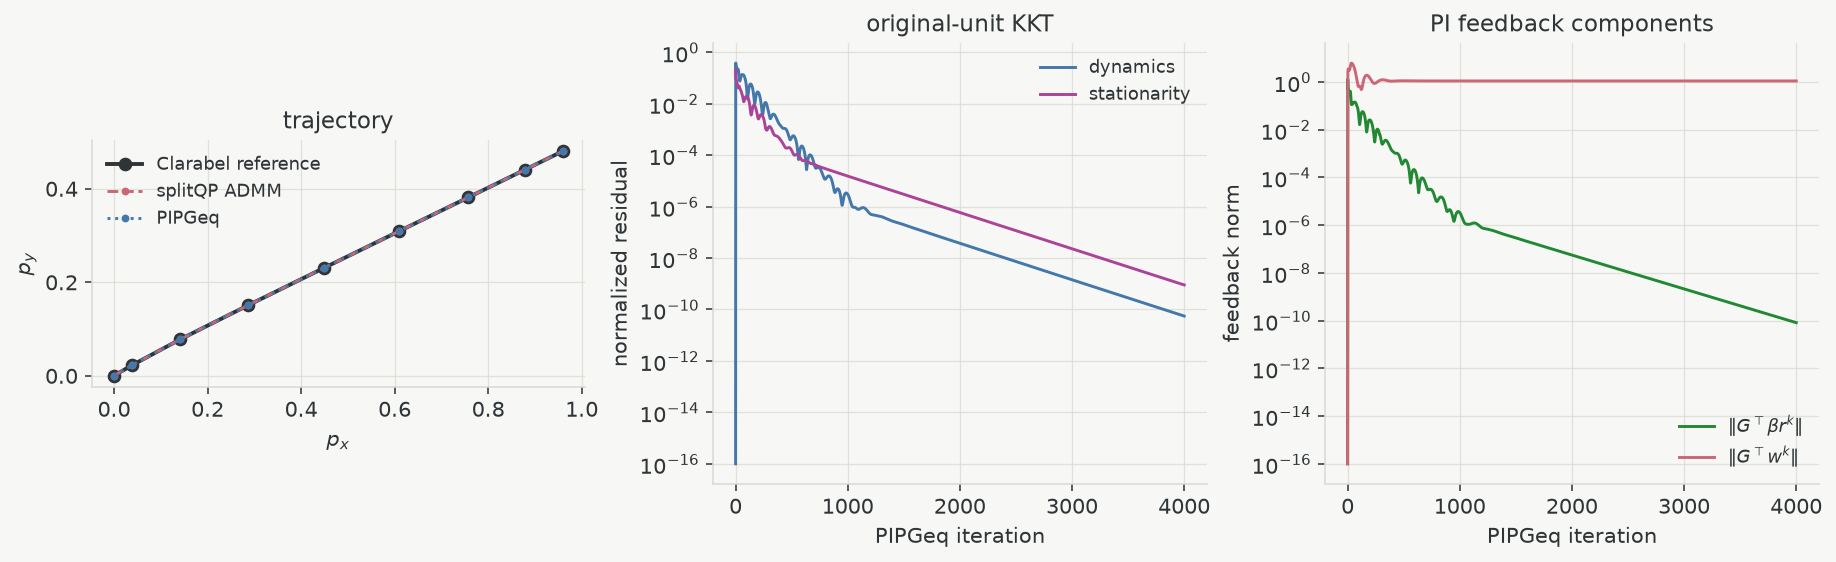

In [14]:
blue, orange, green, purple, dark, grid = (
    "#4477AA", "#CC6677", "#228833", "#AA4499",
    "#2F3437", "#D9D9D6")

states_ref, controls_ref = unpack_trajectory(B_ref["z"], B)
states_admm, controls_admm = unpack_trajectory(np.asarray(result_B.x), B)
states_pipg, controls_pipg = unpack_trajectory(pipgeq_zs_B[-1], B)

# Compare feedback after mapping both constraint-space terms by G^T.
residuals_B = pipgeq_zs_B @ B["G"].T
proportional_norm = np.linalg.norm(
    (beta_B * residuals_B) @ B["G"], axis=1)
integral_norm = np.linalg.norm(pipgeq_ws_B @ B["G"], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), dpi=140,
                         layout="constrained")
axes[0].plot(states_ref[:, 0], states_ref[:, 1], marker="o",
             color=dark, lw=2, label="Clarabel reference")
axes[0].plot(states_admm[:, 0], states_admm[:, 1], marker=".",
             color=orange, ls="--", label="splitQP ADMM")
axes[0].plot(states_pipg[:, 0], states_pipg[:, 1], marker=".",
             color=blue, ls=":", label="PIPGeq")
axes[0].set(xlabel=r"$p_x$", ylabel=r"$p_y$", title="trajectory")
axes[0].set_aspect("equal")
axes[0].legend(frameon=False)

axes[1].semilogy(np.maximum(pipgeq_diag_B[:, 1], 1e-16),
                 color=blue, label="dynamics")
axes[1].semilogy(np.maximum(pipgeq_diag_B[:, 2], 1e-16),
                 color=purple, label="stationarity")
axes[1].set(xlabel="PIPGeq iteration", ylabel="normalized residual",
            title="original-unit KKT")
axes[1].legend(frameon=False)

axes[2].semilogy(np.maximum(proportional_norm, 1e-16),
                 color=green, label=r"$\|G^\top\beta r^k\|$")
axes[2].semilogy(np.maximum(integral_norm, 1e-16),
                 color=orange, label=r"$\|G^\top w^k\|$")
axes[2].set(xlabel="PIPGeq iteration", ylabel="feedback norm",
            title="PI feedback components")
axes[2].legend(frameon=False)
finish_axes(axes, grid)
plt.show()

**Observation.** Both methods recover the same trajectory and admit
natural warm starts. The difference remains computational: splitQP carries a
reusable factor, while PIPGeq carries the primal state, accumulated dynamics
residual, and inexpensive operator products. Equality feedback nevertheless has
no representation for a norm bound such as $\|u_k\|_2\le r$; that modeling
restriction motivates the cone extension.

### Stage 2 — From equality residuals to general cones

The quadratic cone problem is

$$
\min_{z\in D}\ \tfrac12z^\top Pz+q^\top z
\quad\text{s.t.}\quad Hz-g\in K,
$$

where $H\in\mathbb R^{m\times n}$, $K\subseteq\mathbb R^m$ is a closed convex
cone, and the multiplier follows the paper convention $w\in K^\circ$.
Stationarity is

$$
0\in Pz+q+H^\top w+N_D(z).
$$

An interval row $l_i\le a_i^\top z\le u_i$ has the product-cone encoding

$$
a_i^\top z-l_i\in\mathbb R_+,\qquad
-a_i^\top z+u_i\in\mathbb R_+.
$$

The signs are essential: both associated polar components are nonpositive, and
the physical row multiplier is their signed difference. Equality rows use the
zero cone. Because $\{0\}^\circ=\mathbb R^m$, their correction state is
unrestricted and no polar projection is needed.

In [15]:
# Lower rows use a_i^T z-l_i in R_+; upper rows reverse the sign.
def box_rows_to_product_cone(A_box, lower, upper, atol=0.0):
    H_rows, g_rows, kinds = [], [], []
    for ai, li, ui in zip(np.asarray(A_box), lower, upper):
        if np.isfinite(li) and np.isfinite(ui) and abs(li - ui) <= atol:
            H_rows.append(ai); g_rows.append(li); kinds.append("zero")
        else:
            if np.isfinite(li):
                H_rows.append(ai); g_rows.append(li); kinds.append("lower:R+")
            if np.isfinite(ui):
                H_rows.append(-ai); g_rows.append(-ui); kinds.append("upper:R+")
    return np.asarray(H_rows), np.asarray(g_rows), kinds

H_map, g_map, kinds_map = box_rows_to_product_cone(
    A_split, l_split, u_split)
probes = np.random.default_rng(3).normal(size=(20, 2))
max_violation_mismatch = 0.0
for z in probes:
    residual = H_map @ z - g_map
    cone_distance = np.linalg.norm(np.concatenate((
        residual[:1], np.minimum(residual[1:], 0.0))))
    box_violation = np.linalg.norm(np.concatenate((
        A["G"] @ z - A["g"],
        np.minimum(z - A["lower"], 0.0),
        np.minimum(A["upper"] - z, 0.0))))
    max_violation_mismatch = max(
        max_violation_mismatch, abs(cone_distance - box_violation))

print("mapped row kinds:", kinds_map)
print("maximum box/product-cone distance mismatch:",
      max_violation_mismatch)
print("polar lower and upper states are nonpositive; "
      "box multiplier is w_lower - w_upper")
assert max_violation_mismatch < 1e-12

mapped row kinds: ['zero', 'lower:R+', 'upper:R+', 'lower:R+', 'upper:R+']
maximum box/product-cone distance mismatch: 0.0
polar lower and upper states are nonpositive; box multiplier is w_lower - w_upper


#### General PIPG

For a general cone, the correction must remain in $K^\circ$:

$$
w^{j+1}=\Pi_{K^\circ}[v^j+\beta(Hz^j-g)],
$$

$$
z^{j+1}=\Pi_D[z^j-\alpha(Pz^j+q+H^\top w^{j+1})],
$$

$$
v^{j+1}=w^{j+1}+\beta H(z^{j+1}-z^j).
$$

The first line forms the current residual correction and projects it onto the
admissible multiplier cone. The second returns that correction to primal space.
The last line predicts the correction associated with the new primal point;
together the first and third lines constitute the prediction--correction form
of the PI state. The new computational requirement relative to PIPGeq is
$\Pi_{K^\circ}$, whose cost depends on the cone representation.

In [16]:
class ConicData(NamedTuple):
    P: jax.Array
    q: jax.Array
    H: jax.Array
    g: jax.Array
    lower: jax.Array
    upper: jax.Array
    alpha: jax.Array
    beta: jax.Array

class PIPGState(NamedTuple):
    z: jax.Array
    v: jax.Array
    Hz: jax.Array
    w: jax.Array

def pipg_step(data, state, n_zero, n_nonnegative, n_soc):
    # Keep the correction state inside the polar cone (2108.10260, alg: w).
    dual_trial = state.v + data.beta * (state.Hz - data.g)
    w_new = project_product_cone_polar(
        dual_trial, n_zero, n_nonnegative, n_soc)
    # Return the cone correction to primal space (alg: z).
    gradient = data.P @ state.z + data.q + data.H.T @ w_new
    z_new = project_box(
        state.z - data.alpha * gradient, data.lower, data.upper)
    # Predict the correction at the new primal point (alg: v).
    Hz_new = data.H @ z_new
    v_new = w_new + data.beta * (Hz_new - state.Hz)
    return PIPGState(z_new, v_new, Hz_new, w_new)

@partial(jax.jit, static_argnames=(
    "steps", "n_zero", "n_nonnegative", "n_soc"))
def run_pipg(data, state0, steps, n_zero, n_nonnegative, n_soc):
    def body(state, _):
        state = pipg_step(
            data, state, n_zero, n_nonnegative, n_soc)
        return state, state
    return jax.lax.scan(body, state0, None, length=steps)

##### Equality as the zero-cone case

If $K=\{0\}$, then $K^\circ=\mathbb R^m$ and the polar projection is the
identity. Combining the first and third updates gives

$$
v^{j+1}=v^j+\beta(Hz^{j+1}-g).
$$

Thus $v$ becomes an unconstrained integral state and the general-cone trace
coincides with PIPGeq when the initial states and step sizes are aligned. The
local assertion below checks this equality at the iterate level.

In [17]:
# K={0} makes the polar projection the identity.
data_A_cone = ConicData(
    *map(jnp.asarray, (A["P"], A["q"], A["G"], A["g"],
                       A["lower"], A["upper"])),
    jnp.asarray(alpha_A), jnp.asarray(beta_A))
state0_A_cone = PIPGState(
    z0_A, jnp.zeros(1), data_A_cone.H @ z0_A, jnp.zeros(1))
_, trace_A_cone = run_pipg(
    data_A_cone, state0_A_cone, steps=100,
    n_zero=1, n_nonnegative=0, n_soc=0)
equality_recovery_error = max(
    np.max(np.abs(np.asarray(trace_A_cone.z)
                  - np.asarray(pipgeq_trace_A.z[:100]))),
    np.max(np.abs(np.asarray(trace_A_cone.v)
                  - np.asarray(pipgeq_trace_A.w[:100]))))
assert equality_recovery_error < 1e-11

#### Constant-step PIPG and PDHG

For constant $\beta$, the preceding PIPG iteration implies

$$
v^j=w^j+\beta H(z^j-z^{j-1}).
$$

Substitution into the polar update yields the single identity

$$
w^{j+1}=\Pi_{K^\circ}\!\left[
w^j+\beta\{H(2z^j-z^{j-1})-g\}\right].
$$

Together with the projected primal-forward step, and after the corresponding
index shift, this is the constant-step forward PDHG form displayed in the PIPG
paper. The statement is algebraic but specific: it does not identify
varying-step PIPG, relaxed xPIPG with $\rho\ne1$, or every algorithm bearing the
PDHG name with the same iteration.

In [18]:
class PDHGState(NamedTuple):
    z: jax.Array
    w: jax.Array

# Constant-step forward PDHG form obtained by eliminating PIPG's v state.
def pdhg_forward_step(data, state, n_zero, n_nonnegative, n_soc):
    z_new = project_box(
        state.z - data.alpha * (
            data.P @ state.z + data.q + data.H.T @ state.w),
        data.lower, data.upper)
    w_new = project_product_cone_polar(
        state.w + data.beta * (
            data.H @ (2.0 * z_new - state.z) - data.g),
        n_zero, n_nonnegative, n_soc)
    return PDHGState(z_new, w_new)

def run_python_steps(step_fn, state0, count):
    states, state = [], state0
    for _ in range(count):
        state = step_fn(state)
        states.append(state)
    return states

# Use the analytically feasible SOC trajectory so v0 = -beta(Hz0-g)
# belongs to the polar product cone when w0=0.
ratio_C = 1.0
normP_C = np.linalg.norm(C_feas["P"], 2)
normH_C = np.linalg.norm(C_feas["H"], 2)
alpha_C_pipg = 1.0 / (normP_C + ratio_C * normH_C**2)
beta_C_pipg = ratio_C
data_C_pipg = ConicData(
    *map(jnp.asarray, (
        C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
        C_feas["lower"], C_feas["upper"])),
    jnp.asarray(alpha_C_pipg), jnp.asarray(beta_C_pipg))
z_parity = jnp.asarray(z_known)
w_parity = jnp.zeros(C_feas["H"].shape[0])
v_parity = w_parity - beta_C_pipg * (
    data_C_pipg.H @ z_parity - data_C_pipg.g)
pipg_parity0 = PIPGState(
    z_parity, v_parity, data_C_pipg.H @ z_parity, w_parity)
pdhg_parity0 = PDHGState(z_parity, w_parity)

pipg_states = run_python_steps(
    lambda s: pipg_step(
        data_C_pipg, s, C_feas["n_zero"], 0, C_feas["n_soc"]),
    pipg_parity0, 20)
pdhg_states = run_python_steps(
    lambda s: pdhg_forward_step(
        data_C_pipg, s, C_feas["n_zero"], 0, C_feas["n_soc"]),
    pdhg_parity0, 20)
parity_error = max(
    np.linalg.norm(np.asarray(ps.z) - np.asarray(ds.z))
    for ps, ds in zip(pipg_states, pdhg_states))
assert parity_error < 1e-9

#### Why equality feedback is insufficient

Problem C retains Problem B's objective, dynamics, and componentwise bounds,
then adds

$$
H_Cz-g_C\in\{0\}^{32}\times\mathcal Q_3^8,\qquad
(u_{x,k},u_{y,k},r)\in\mathcal Q_3.
$$

An equality-only method can satisfy the dynamics and the component box while
violating $\|u_k\|_2\le r$. General PIPG associates the SOC rows with a polar
SOC block, so the corresponding component of $H_C^\top w$ supplies precisely
the feedback absent from PIPGeq.

In [19]:
# Equality-only relaxation of the feasible conic problem.
alpha_Ceq, beta_Ceq, _, _ = pipgeq_parameters(
    C_feas["P"], C_feas["G"])
data_Ceq = PIPGeqData(
    *map(jnp.asarray, (
        C_feas["P"], C_feas["q"], C_feas["G"], C_feas["g_eq"],
        C_feas["lower"], C_feas["upper"])),
    jnp.asarray(alpha_Ceq), jnp.asarray(beta_Ceq))
z0_C = project_box(jnp.zeros(C_feas["n"]), data_Ceq.lower, data_Ceq.upper)
state0_Ceq = PIPGeqState(
    z0_C, jnp.zeros(C_feas["G"].shape[0]),
    data_Ceq.G @ z0_C - data_Ceq.g)
_, trace_Ceq = run_pipgeq(data_Ceq, state0_Ceq, steps=5000)
z_Ceq = np.asarray(trace_Ceq.z[-1])

# General PIPG uses the 2108.10260 constant-step relation
# alpha(lambda + beta ||H||^2) = 1 for this explicit matrix.
beta_C = math.sqrt(normP_C / (normH_C**2))
alpha_C = 1.0 / (normP_C + normH_C**2 * beta_C)
data_C = ConicData(
    *map(jnp.asarray, (
        C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
        C_feas["lower"], C_feas["upper"])),
    jnp.asarray(alpha_C), jnp.asarray(beta_C))
v0_C = project_product_cone_polar(
    jnp.zeros(C_feas["H"].shape[0]),
    C_feas["n_zero"], 0, C_feas["n_soc"])
state0_C = PIPGState(
    z0_C, v0_C, data_C.H @ z0_C, jnp.zeros_like(v0_C))
_, trace_C = run_pipg(
    data_C, state0_C, steps=6000,
    n_zero=C_feas["n_zero"], n_nonnegative=0, n_soc=C_feas["n_soc"])
zs_C = np.vstack((np.asarray(z0_C)[None], np.asarray(trace_C.z)))
ws_C = np.vstack((
    np.zeros((1, C_feas["H"].shape[0])), np.asarray(trace_C.w)))
diag_C = trace_diagnostics(
    C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
    C_feas["lower"], C_feas["upper"], zs_C, ws_C,
    C_feas["n_zero"], 0, C_feas["n_soc"])

_, controls_eq_only = unpack_trajectory(z_Ceq, C_feas)
_, controls_general = unpack_trajectory(zs_C[-1], C_feas)
eq_only_max = np.linalg.norm(controls_eq_only, axis=1).max()
general_max = np.linalg.norm(controls_general, axis=1).max()
print(f"equality-only max ||u||: {eq_only_max:.6f}")
print(f"general PIPG max ||u||: {general_max:.6f}")
print("general PIPG first common KKT <=1e-6:",
      first_below(diag_C, 1e-6))
sparse_log("general PIPG, feasible SOC", diag_C,
           iterations=(0, 1, 2, 10, 100, 500, 2000, 6000))

equality-only max ||u||: 1.411026
general PIPG max ||u||: 1.200000
general PIPG first common KKT <=1e-6: 4062

general PIPG, feasible SOC
   iter     objective      primal  stationarity        cone
      0     -6.250000    2.03e-01      7.04e-02    2.44e-01
      1     -6.496453    1.79e-01      8.49e-02    1.55e-01
      2     -6.745237    1.52e-01      8.50e-02    1.07e-01
     10     -7.540809    9.29e-02      7.15e-02    3.91e-02
    100     -7.153345    7.52e-03      1.67e-02    3.45e-03
    500     -7.120546    2.69e-03      2.05e-03    2.25e-03
   2000     -7.212202    5.16e-05      2.12e-05    4.37e-05
   6000     -7.213405    3.50e-08      3.58e-08    2.93e-08


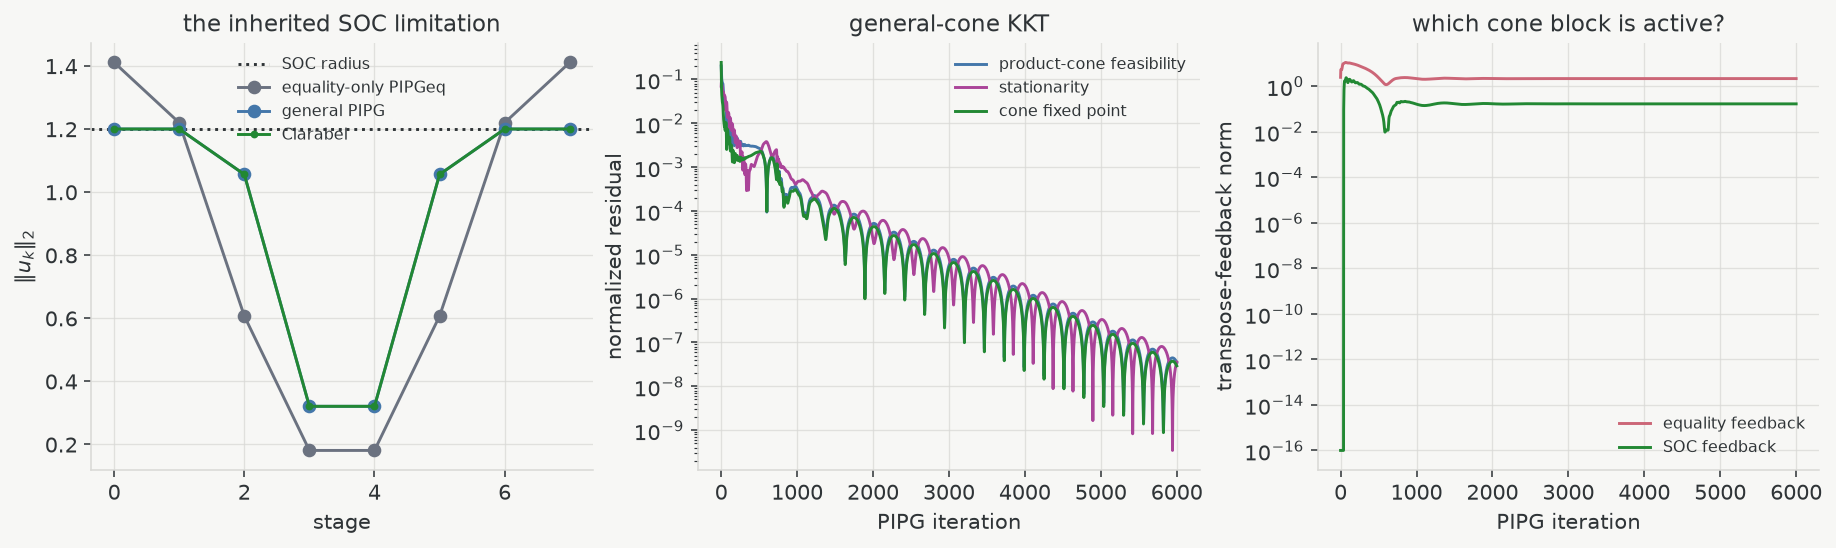

In [20]:
blue, orange, green, purple, gray, dark, grid = (
    "#4477AA", "#CC6677", "#228833", "#AA4499",
    "#6B7280", "#2F3437", "#D9D9D6")

control_norm_eq = np.linalg.norm(controls_eq_only, axis=1)
control_norm_general = np.linalg.norm(controls_general, axis=1)
control_norm_ref = np.linalg.norm(
    unpack_trajectory(C_feas_ref["z"], C_feas)[1], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=140,
                         layout="constrained")
stages = np.arange(C_feas["N"])
axes[0].axhline(C_feas["radius"], color=dark, ls=":", label="SOC radius")
axes[0].plot(stages, control_norm_eq, marker="o", color=gray,
             label="equality-only PIPGeq")
axes[0].plot(stages, control_norm_general, marker="o", color=blue,
             label="general PIPG")
axes[0].plot(stages, control_norm_ref, marker=".", color=green,
             label="Clarabel")
axes[0].set(xlabel="stage", ylabel=r"$\|u_k\|_2$",
            title="the inherited SOC limitation")
axes[0].legend(frameon=False, fontsize=8)

axes[1].semilogy(np.maximum(diag_C[:, 1], 1e-16), color=blue,
                 label="product-cone feasibility")
axes[1].semilogy(np.maximum(diag_C[:, 2], 1e-16), color=purple,
                 label="stationarity")
axes[1].semilogy(np.maximum(diag_C[:, 3], 1e-16), color=green,
                 label="cone fixed point")
axes[1].set(xlabel="PIPG iteration", ylabel="normalized residual",
            title="general-cone KKT")
axes[1].legend(frameon=False, fontsize=8)

# Split H^T w by cone block to identify the source of feedback.
eq_feedback = np.linalg.norm(
    np.asarray(trace_C.w)[:, :C_feas["n_zero"]] @
    C_feas["H"][:C_feas["n_zero"]], axis=1)
soc_feedback = np.linalg.norm(
    np.asarray(trace_C.w)[:, C_feas["n_zero"]:] @
    C_feas["H"][C_feas["n_zero"]:], axis=1)
axes[2].semilogy(np.maximum(eq_feedback, 1e-16), color=orange,
                 label="equality feedback")
axes[2].semilogy(np.maximum(soc_feedback, 1e-16), color=green,
                 label="SOC feedback")
axes[2].set(xlabel="PIPG iteration", ylabel="transpose-feedback norm",
            title="which cone block is active?")
axes[2].legend(frameon=False, fontsize=8)
finish_axes(axes, grid)
plt.show()

**Observation.** The cone extension changes the admissible model, not
the basic feedback architecture. Its online cost remains modest in this example
because the zero-cone and SOC polar projections are closed form. The numerical
comparison separates equality and SOC components of $H^\top w$ and shows that
the latter is active exactly where the equality-only solution violates the norm
bound.

### Stage 3 — xPIPG: relaxation and infeasibility signals

xPIPG applies relaxation to the fixed-point states $(\xi,\eta)$. The projected
base points are

$$
z^+=\Pi_D[\xi-\alpha(P\xi+q+H^\top\eta)],
$$

$$
w^+=\Pi_{K^\circ}
[\eta+\beta(H(2z^+-\xi)-g)],
$$

and the persistent states are updated by

$$
\xi^+=(1-\rho)\xi+\rho z^+,\qquad
\eta^+=(1-\rho)\eta+\rho w^+.
$$

The projected points $(z^+,w^+)$ and relaxed states $(\xi^+,\eta^+)$ have
distinct roles and are therefore stored separately. For $0<\rho<1$ the map is
under-relaxed; $\rho=1$ gives the unrelaxed PIPG/PDHG representation; and
$1<\rho<2$ extrapolates the fixed-point state. This is relaxation of an averaged
operator, not Nesterov momentum.

In [21]:
class XPIPGState(NamedTuple):
    xi: jax.Array
    eta: jax.Array
    z: jax.Array
    w: jax.Array

def xpipg_step(data, state, rho_relax, n_zero, n_nonnegative, n_soc):
    # Primal base point (2203.04188, alg: z).
    z_new = project_box(
        state.xi - data.alpha * (
            data.P @ state.xi + data.q + data.H.T @ state.eta),
        data.lower, data.upper)
    # Extrapolate the primal point before the polar projection (alg: w).
    w_new = project_product_cone_polar(
        state.eta + data.beta * (
            data.H @ (2.0 * z_new - state.xi) - data.g),
        n_zero, n_nonnegative, n_soc)
    # Relax the fixed-point states (alg: relaxed z, alg: relaxed w).
    xi_new = (1.0 - rho_relax) * state.xi + rho_relax * z_new
    eta_new = (1.0 - rho_relax) * state.eta + rho_relax * w_new
    return XPIPGState(xi_new, eta_new, z_new, w_new)

@partial(jax.jit, static_argnames=(
    "steps", "n_zero", "n_nonnegative", "n_soc"))
def run_xpipg(data, state0, rho_relax, steps,
              n_zero, n_nonnegative, n_soc):
    def body(state, _):
        state = xpipg_step(
            data, state, rho_relax, n_zero, n_nonnegative, n_soc)
        return state, state
    return jax.lax.scan(body, state0, None, length=steps)

@partial(jax.jit, static_argnames=(
    "steps", "n_zero", "n_nonnegative", "n_soc"))
def run_xpipg_final(data, state0, rho_relax, steps,
                   n_zero, n_nonnegative, n_soc):
    def body(_, state):
        return xpipg_step(
            data, state, rho_relax, n_zero, n_nonnegative, n_soc)
    return jax.lax.fori_loop(0, steps, body, state0)

# Parameterize beta=(beta/alpha) alpha, then stay inside the strict bound.
def safe_xpipg_steps(P, H, beta_over_alpha=1.0, safety=0.99,
                     norm_H_override=None):
    norm_P = float(np.linalg.norm(P, 2))
    norm_H = (float(np.linalg.norm(H, 2)) if norm_H_override is None
              else float(norm_H_override))
    ratio = float(beta_over_alpha)
    alpha = safety * 2.0 / (
        norm_P + math.sqrt(norm_P**2 + 4.0 * ratio * norm_H**2))
    beta = ratio * alpha
    margin = alpha * (norm_P + beta * norm_H**2)
    return alpha, beta, norm_P, norm_H, margin

alpha_xC, beta_xC, normP_xC, normH_xC, margin_xC = safe_xpipg_steps(
    C_feas["P"], C_feas["H"], beta_over_alpha=1.0)
data_xC_feas = ConicData(
    *map(jnp.asarray, (
        C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
        C_feas["lower"], C_feas["upper"])),
    jnp.asarray(alpha_xC), jnp.asarray(beta_xC))
data_xC_infeas = data_xC_feas._replace(g=jnp.asarray(C_infeas["g"]))
z0_xC = project_box(
    jnp.zeros(C_feas["n"]), data_xC_feas.lower, data_xC_feas.upper)
state0_xC = XPIPGState(
    z0_xC, jnp.zeros(C_feas["H"].shape[0]),
    z0_xC, jnp.zeros(C_feas["H"].shape[0]))

print(f"||P||={normP_xC:.6g}, ||H||={normH_xC:.6g}")
print(f"alpha={alpha_xC:.8f}, beta={beta_xC:.8f}, "
      f"alpha(||P||+beta||H||^2)={margin_xC:.8f}")
assert margin_xC < 1.0

||P||=10, ||H||=2.10969
alpha=0.09494712, beta=0.09494712, alpha(||P||+beta||H||^2)=0.98959471


#### Direct update and compiled scan

The first implementation mirrors the four equations without algebraic fusion.
`lax.scan` then applies the same pure update while retaining a complete trace.
A local equality check ensures that compilation changes the execution schedule,
not the fixed-point map, before the compiled form is used for longer runs.

In [22]:
# The direct loop and compiled scan must produce the same base states.
plain_states = run_python_steps(
    lambda s: xpipg_step(
        data_xC_feas, s, 1.4,
        C_feas["n_zero"], 0, C_feas["n_soc"]),
    state0_xC, 20)
_, compiled_states = run_xpipg(
    data_xC_feas, state0_xC, jnp.asarray(1.4), steps=20,
    n_zero=C_feas["n_zero"], n_nonnegative=0, n_soc=C_feas["n_soc"])
compiled_plain_error = max(
    np.linalg.norm(np.asarray(a.z) - np.asarray(b))
    for a, b in zip(plain_states, np.asarray(compiled_states.z)))
assert compiled_plain_error < 1e-11

##### The checkpoint $\rho=1$

At $\rho=1$, the relaxed states become the newly projected base points:
$\xi^+=z^+$ and $\eta^+=w^+$. Starting from the same primal and polar states,
the xPIPG update therefore coincides with the primal-first constant-step PDHG
update used above. This identity is checked over successive iterates rather than
only at the final solution.

In [23]:
# With rho=1, relaxed states are exactly the new projected base points.
data_parity_x = data_C_pipg._replace(
    alpha=jnp.asarray(alpha_C_pipg), beta=jnp.asarray(beta_C_pipg))
state_x_parity = XPIPGState(
    z_parity, w_parity, z_parity, w_parity)
state_d_parity = PDHGState(z_parity, w_parity)
rho_one_errors = []
for _ in range(20):
    state_x_parity = xpipg_step(
        data_parity_x, state_x_parity, 1.0,
        C_feas["n_zero"], 0, C_feas["n_soc"])
    state_d_parity = pdhg_forward_step(
        data_parity_x, state_d_parity,
        C_feas["n_zero"], 0, C_feas["n_soc"])
    rho_one_errors.append(
        np.linalg.norm(np.asarray(state_x_parity.z)
                       - np.asarray(state_d_parity.z))
        + np.linalg.norm(np.asarray(state_x_parity.w)
                         - np.asarray(state_d_parity.w)))
assert max(rho_one_errors) < 1e-9

#### Relaxation sweep

The admissible interval does not determine a universally best relaxation.
Holding the instance, initialization, $(\alpha,\beta)$, KKT tolerance, and
iteration budget fixed, compare

$$
\rho\in\{0.8,1.0,1.2,1.4,1.6,1.8,1.95\}.
$$

The selected value is the one that first reaches the common KKT tolerance on
this instance. The reference solution is not consulted in the selection, and
the result is not transferred to a different problem without measurement.

In [24]:
RHO_RELAX_GRID = np.array([0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 1.95])
rho_rows, rho_traces = [], {}
for rho_relax in RHO_RELAX_GRID:
    _, trace = run_xpipg(
        data_xC_feas, state0_xC, jnp.asarray(rho_relax), steps=5000,
        n_zero=C_feas["n_zero"], n_nonnegative=0, n_soc=C_feas["n_soc"])
    zs = np.vstack((np.asarray(z0_xC)[None], np.asarray(trace.z)))
    ws = np.vstack((
        np.zeros((1, C_feas["H"].shape[0])), np.asarray(trace.w)))
    diag = trace_diagnostics(
        C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
        C_feas["lower"], C_feas["upper"], zs, ws,
        C_feas["n_zero"], 0, C_feas["n_soc"])
    hit = first_below(diag, 1e-6)
    final_kkt = float(np.max(diag[-1, 1:]))
    rho_rows.append((rho_relax, hit, final_kkt))
    rho_traces[float(rho_relax)] = (trace, zs, ws, diag)

# Select by first KKT hit only; no reference-solution error enters the rule.
valid_rows = [row for row in rho_rows if row[1] is not None]
rho_selected = min(valid_rows, key=lambda row: row[1])[0] if valid_rows else 1.0
print(f"{'rho_relax':>9} {'iterations':>12} {'final KKT':>13}")
for rho_relax, hit, final_kkt in rho_rows:
    print(f"{rho_relax:>9.2f} {str(hit):>12} {final_kkt:>13.2e}")
print(f"selected rho_relax={rho_selected:.2f}")

rho_relax   iterations     final KKT
     0.80         3804      1.86e-07
     1.00         3046      2.06e-08
     1.20         2541      1.58e-09
     1.40         2180      9.97e-11
     1.60         1912      4.89e-12
     1.80         2042      1.67e-13
     1.95         1885      6.98e-14
selected rho_relax=1.95


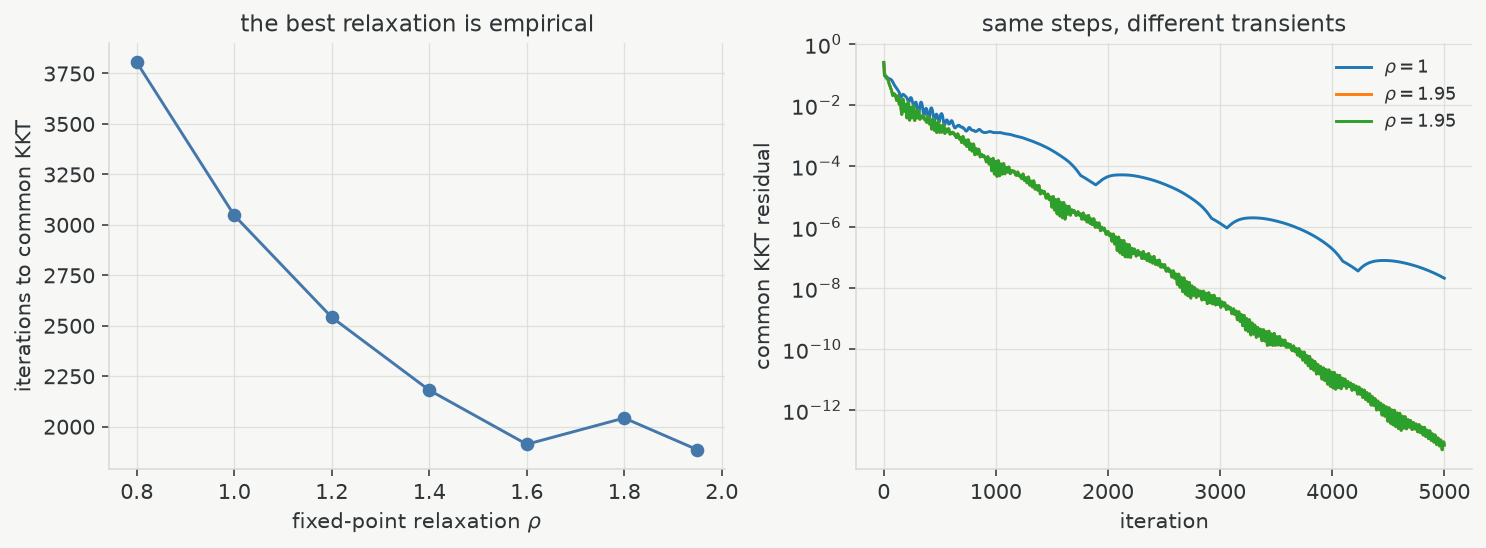

In [25]:
blue, orange, grid = "#4477AA", "#CC6677", "#D9D9D6"

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), dpi=140,
                         layout="constrained")
plotted_iters = [
    5000 if row[1] is None else row[1] for row in rho_rows]
axes[0].plot(RHO_RELAX_GRID, plotted_iters, marker="o", color=blue)
for rho_relax, hit, _ in rho_rows:
    if hit is None:
        axes[0].annotate("max", (rho_relax, 5000),
                         xytext=(0, 5), textcoords="offset points",
                         ha="center", fontsize=8, color=orange)
axes[0].set(xlabel=r"fixed-point relaxation $\rho$",
            ylabel="iterations to common KKT",
            title="the best relaxation is empirical")

for rho_relax in (1.0, float(rho_selected), 1.95):
    diag = rho_traces[rho_relax][3]
    axes[1].semilogy(
        np.maximum(np.max(diag[:, 1:], axis=1), 1e-16),
        label=fr"$\rho={rho_relax:g}$")
axes[1].set(xlabel="iteration", ylabel="common KKT residual",
            title="same steps, different transients")
axes[1].legend(frameon=False)
finish_axes(axes, grid)
plt.show()

#### Matched feasible and infeasible traces

The two instances differ only in the SOC radius, $1.2$ versus $1.0$. They use
the same step sizes, selected relaxation, initial state, and iteration budget.

The xPIPG termination quantities are the normalized differences of successive
projected base points,

$$
d_z^k=\frac{\|z^{k+1}-z^k\|}{\alpha\rho},\qquad
d_w^k=\frac{\|w^{k+1}-w^k\|}{\beta\rho}.
$$

For the averaged fixed-point map, the unscaled vector differences converge to
components of a minimal-displacement direction under the paper's assumptions.
In finite precision, persistence of $d_z^k$ or $d_w^k$ identifies a candidate
direction; cone membership and separation or recession tests are still needed
before assigning an infeasibility status.

In [26]:
_, trace_feas = run_xpipg(
    data_xC_feas, state0_xC, jnp.asarray(rho_selected), steps=8000,
    n_zero=C_feas["n_zero"], n_nonnegative=0, n_soc=C_feas["n_soc"])
_, trace_infeas = run_xpipg(
    data_xC_infeas, state0_xC, jnp.asarray(rho_selected), steps=8000,
    n_zero=C_infeas["n_zero"], n_nonnegative=0, n_soc=C_infeas["n_soc"])

# Certificates use projected base points z,w rather than relaxed xi,eta.
def base_arrays(trace, state0):
    zs = np.vstack((np.asarray(state0.z)[None], np.asarray(trace.z)))
    ws = np.vstack((np.asarray(state0.w)[None], np.asarray(trace.w)))
    return zs, ws

zf, wf = base_arrays(trace_feas, state0_xC)
zi, wi = base_arrays(trace_infeas, state0_xC)
diag_feas = trace_diagnostics(
    C_feas["P"], C_feas["q"], C_feas["H"], C_feas["g"],
    C_feas["lower"], C_feas["upper"], zf, wf,
    C_feas["n_zero"], 0, C_feas["n_soc"])
diag_infeas = trace_diagnostics(
    C_infeas["P"], C_infeas["q"], C_infeas["H"], C_infeas["g"],
    C_infeas["lower"], C_infeas["upper"], zi, wi,
    C_infeas["n_zero"], 0, C_infeas["n_soc"])

dz_feas = np.linalg.norm(np.diff(zf, axis=0), axis=1) / (
    alpha_xC * rho_selected)
dw_feas = np.linalg.norm(np.diff(wf, axis=0), axis=1) / (
    beta_xC * rho_selected)
dz_infeas = np.linalg.norm(np.diff(zi, axis=0), axis=1) / (
    alpha_xC * rho_selected)
dw_infeas = np.linalg.norm(np.diff(wi, axis=0), axis=1) / (
    beta_xC * rho_selected)

print(f"{'case':<12} {'final KKT':>12} {'mean d_z':>12} "
      f"{'mean d_w':>12}")
print(f"{'feasible':<12} {np.max(diag_feas[-1, 1:]):>12.2e} "
      f"{np.mean(dz_feas[-50:]):>12.2e} "
      f"{np.mean(dw_feas[-50:]):>12.2e}")
print(f"{'infeasible':<12} {np.max(diag_infeas[-1, 1:]):>12.2e} "
      f"{np.mean(dz_infeas[-50:]):>12.2e} "
      f"{np.mean(dw_infeas[-50:]):>12.2e}")

case            final KKT     mean d_z     mean d_w
feasible         7.92e-16     6.24e-15     6.44e-15
infeasible       5.35e-03     1.51e-14     3.56e-02


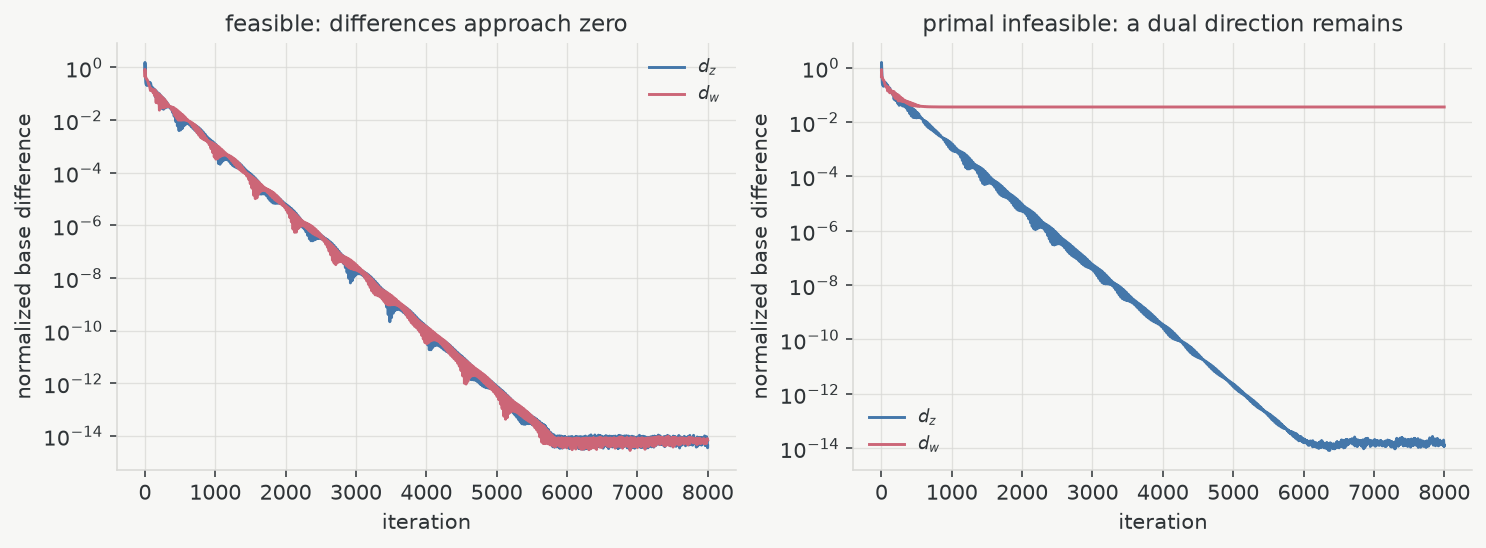

In [27]:
blue, orange, grid = "#4477AA", "#CC6677", "#D9D9D6"

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), dpi=140,
                         layout="constrained")
axes[0].semilogy(np.maximum(dz_feas, 1e-16), color=blue,
                 label=r"$d_z$")
axes[0].semilogy(np.maximum(dw_feas, 1e-16), color=orange,
                 label=r"$d_w$")
axes[0].set(xlabel="iteration", ylabel="normalized base difference",
            title="feasible: differences approach zero")
axes[0].legend(frameon=False)

axes[1].semilogy(np.maximum(dz_infeas, 1e-16), color=blue,
                 label=r"$d_z$")
axes[1].semilogy(np.maximum(dw_infeas, 1e-16), color=orange,
                 label=r"$d_w$")
axes[1].set(xlabel="iteration", ylabel="normalized base difference",
            title="primal infeasible: a dual direction remains")
axes[1].legend(frameon=False)
finish_axes(axes, grid)
plt.show()

#### A primal-infeasibility direction

To reduce finite-iteration oscillation, estimate the limiting dual displacement
by averaging the last $s$ base-dual differences and normalizing:

$$
\widetilde w=
\frac{\frac1s\sum(w^{i+1}-w^i)}
{\left\|\frac1s\sum(w^{i+1}-w^i)\right\|}.
$$

A primal-infeasibility separator must satisfy

$$
\operatorname{dist}(\widetilde w,K^\circ)\approx0,
$$

and the strict separation condition

$$
\inf_{z\in[\ell,u]}
\langle Hz-g,\widetilde w\rangle>0.
$$

Because $\widetilde w\in K^\circ$, the support of $K$ in this direction is
zero; the second inequality therefore separates the attainable residual set
$\{Hz-g:z\in D\}$ from $K$. For a box, the infimum is evaluated exactly by
choosing one bound per component. Agreement between adjacent averaging windows
is reported as a finite-iteration stability check, not as part of the theorem.

In [28]:
def primal_certificate_box(problem, ws, window=50):
    # Average a finite tail as an estimator of the limiting displacement.
    differences = np.diff(np.asarray(ws), axis=0)
    mean_difference = differences[-window:].mean(axis=0)
    norm_direction = np.linalg.norm(mean_difference)
    if norm_direction == 0.0:
        return dict(norm=0.0, polar_distance=np.inf,
                    separation=-np.inf, cosine=0.0)
    direction = mean_difference / norm_direction
    projected = np.asarray(project_product_cone_polar(
        jnp.asarray(direction), problem["n_zero"],
        problem["n_nonnegative"], problem["n_soc"]))
    polar_distance = np.linalg.norm(direction - projected)
    # Evaluate inf_{z in [l,u]} <Hz-g,direction> exactly.
    a = problem["H"].T @ direction
    linear_min = np.sum(np.where(
        a >= 0.0, a * problem["lower"], a * problem["upper"]))
    separation = linear_min - problem["g"] @ direction

    # Adjacent-window cosine measures directional stability.
    prev = differences[-2 * window:-window].mean(axis=0)
    if np.linalg.norm(prev) == 0.0:
        cosine = 0.0
    else:
        cosine = float(
            mean_difference @ prev
            / (np.linalg.norm(mean_difference) * np.linalg.norm(prev)))
    return dict(norm=norm_direction, polar_distance=polar_distance,
                separation=float(separation), cosine=cosine,
                direction=direction)

certificate_rows = []
for window in (20, 50, 100, 200):
    cf = primal_certificate_box(C_feas, wf, window)
    ci = primal_certificate_box(C_infeas, wi, window)
    certificate_rows.append((window, "feasible", cf))
    certificate_rows.append((window, "infeasible", ci))

print(f"{'window':>7} {'trace':>11} {'||mean dw||':>13} "
      f"{'polar dist':>12} {'separation':>12} {'cosine':>9}")
for window, label, row in certificate_rows:
    print(f"{window:>7} {label:>11} {row['norm']:>13.2e} "
          f"{row['polar_distance']:>12.2e} "
          f"{row['separation']:>12.4e} {row['cosine']:>9.5f}")

cert_infeas = primal_certificate_box(C_infeas, wi, 100)
assert cert_infeas["polar_distance"] < 1e-6
assert cert_infeas["separation"] > 1e-5
assert cert_infeas["cosine"] > 0.99

 window       trace   ||mean dw||   polar dist   separation    cosine
     20    feasible      9.34e-16     6.14e-01  -3.7988e+00  -0.92118
     20  infeasible      6.60e-03     3.89e-15   3.5642e-02   1.00000
     50    feasible      8.01e-17     3.41e-01  -7.2317e+00   0.31212
     50  infeasible      6.60e-03     1.16e-15   3.5642e-02   1.00000
    100    feasible      5.54e-17     3.64e-01  -5.8347e+00  -0.03978
    100  infeasible      6.60e-03     9.38e-16   3.5642e-02   1.00000
    200    feasible      3.97e-17     4.27e-01  -5.4003e+00  -0.25149
    200  infeasible      6.60e-03     3.71e-16   3.5642e-02   1.00000


#### Dual infeasibility and unboundedness

A nonzero primal displacement $d$ is an improving recession direction when

$$
d\in\operatorname{rec}D,\qquad Hd\in K,\qquad Pd=0,
\qquad q^\top d<0.
$$

Problems A--C have bounded $D$ and $P\succ0$, so
$\operatorname{rec}D=\{0\}$ and $Pd=0$ excludes a nonzero direction. The
one-dimensional problem

$$
\min_{z\in\mathbb R}-z,qquad P=0,quad q=-1
$$

removes those exclusions and isolates the dual-infeasible/unbounded branch. It
is intentionally a separate microexample because the matched SOC pair can
exhibit primal, but not dual, infeasibility.

In [29]:
P_unb = np.zeros((1, 1))
q_unb = np.array([-1.0])
H_unb = np.zeros((0, 1))
g_unb = np.zeros(0)
data_unb = ConicData(
    *map(jnp.asarray, (
        P_unb, q_unb, H_unb, g_unb,
        np.array([-np.inf]), np.array([np.inf]))),
    jnp.asarray(1.0), jnp.asarray(1.0))
state_unb0 = XPIPGState(
    jnp.zeros(1), jnp.zeros(0), jnp.zeros(1), jnp.zeros(0))
_, trace_unb = run_xpipg(
    data_unb, state_unb0, jnp.asarray(1.4), steps=50,
    n_zero=0, n_nonnegative=0, n_soc=0)
z_unb = np.vstack((np.zeros((1, 1)), np.asarray(trace_unb.z)))
# Estimate the improving recession direction from the final base differences.
direction_unb = np.diff(z_unb, axis=0)[-10:].mean(axis=0)
direction_unb /= np.linalg.norm(direction_unb)

z_ref_unb = cp.Variable()
prob_unb = cp.Problem(cp.Minimize(-z_ref_unb))
prob_unb.solve(solver="CLARABEL")
tests_unb = {
    "||P d||": np.linalg.norm(P_unb @ direction_unb),
    "q' d": float(q_unb @ direction_unb),
    "in rec(D)": True,
    "CVXPY status": prob_unb.status,
}
for key, value in tests_unb.items():
    print(f"{key:<14}{value}")
assert tests_unb["||P d||"] < 1e-12
assert tests_unb["q' d"] < -0.9
assert prob_unb.status == "unbounded"

||P d||       0.0
q' d          -1.0
in rec(D)     True
CVXPY status  unbounded


#### Finite-iteration status

The status rule first tests the common KKT residual. If it has not converged, a
primal-infeasibility label additionally requires a nontrivial displacement,
membership in $K^\circ$, strict separation, and directional stability. The
unbounded microexample is checked against recession feasibility, $Pd=0$, and
strict objective decrease.

Any trace that satisfies neither a KKT test nor all tests for one certificate
remains numerically ambiguous. In particular, the magnitude of one successive
difference is not a certificate, and a small difference alone is not an
optimality condition. The `likely_` prefix records the finite tolerance and
window dependence of the numerical classification.

In [30]:
# Prefer a KKT conclusion; otherwise require every separator test.
def classify_trace(final_diag, certificate=None, *,
                   kkt_tol=1e-6, sep_tol=1e-5,
                   polar_tol=1e-6, cosine_tol=0.99):
    evidence = {"final_kkt": float(np.max(final_diag[1:]))}
    if not np.all(np.isfinite(final_diag)):
        return "numerical_error", evidence
    if evidence["final_kkt"] <= kkt_tol:
        return "converged_feasible", evidence
    if certificate is not None:
        evidence.update({
            "difference_norm": certificate["norm"],
            "polar_distance": certificate["polar_distance"],
            "separation": certificate["separation"],
            "direction_cosine": certificate["cosine"],
        })
        if (certificate["norm"] > 1e-10
                and certificate["polar_distance"] <= polar_tol
                and certificate["separation"] > sep_tol
                and certificate["cosine"] >= cosine_tol):
            return "likely_primal_infeasible", evidence
    return "numerically_ambiguous", evidence

status_feas, evidence_feas = classify_trace(
    diag_feas[-1], primal_certificate_box(C_feas, wf, 100))
status_infeas, evidence_infeas = classify_trace(
    diag_infeas[-1], cert_infeas)
status_unb = "likely_dual_infeasible_or_unbounded"

print(f"feasible   | {status_feas:<33} | "
      f"KKT={evidence_feas['final_kkt']:.2e}")
print(f"infeasible | {status_infeas:<33} | "
      f"polar={evidence_infeas['polar_distance']:.2e} | "
      f"separation={evidence_infeas['separation']:.2e}")
q_directional = tests_unb["q' d"]
print(f"unbounded  | {status_unb:<33} | q'd={q_directional:.2f}")
assert status_feas == "converged_feasible"
assert status_infeas == "likely_primal_infeasible"

feasible   | converged_feasible                | KKT=7.92e-16
infeasible | likely_primal_infeasible          | polar=9.38e-16 | separation=3.56e-02
unbounded  | likely_dual_infeasible_or_unbounded | q'd=-1.00


**Observation.** Relaxation changes the transient of the fixed-point
iteration but not the underlying conic problem. On this instance the best
measured $\rho$ need not be best elsewhere, and values close to $2$ leave less
margin for numerical perturbations. The infeasible trace is distinguished not
merely by a nonvanishing difference, but by a stable polar direction that
strictly separates every residual attainable from the primal box.

### Stage 4 — Preconditioning is the algorithm's geometry

The existing splitQP preconditioning example already shows that an unchanged
QP can require $7256$ ADMM iterations with the default scalar penalty, $174$
with the best scalar on a 49-point grid, and $23$ after row equilibration or the
equivalent diagonal metric. The algorithm is unchanged; the metric seen by its
residuals is not.

For xPIPG, the corresponding stability condition is

$$
\alpha\bigl(\|P\|+\beta\|H\|^2\bigr)<1,
$$

where $\|P\|=\lambda_{\max}(P)$ for the positive-semidefinite objectives used
here. Large operator norms reduce the admissible global step. Uneven singular
directions can also make primal and dual corrections poorly balanced even after
stability has been secured.

Preconditioning changes these quantities before the online iteration begins.
Norm estimation, equilibration, QR, and whitening are setup operations; products
with the transformed $P$, $H$, and $H^\top$, together with the transformed
projections, determine the recurring cost. A useful representation must improve
both sides of this accounting.

#### Operator-norm estimation

The step-size rule requires $\|H\|$. A deterministic power iteration estimates
the dominant eigenvalue of $H^\top H$, followed by a small multiplicative
buffer. The buffer is a practical safeguard after convergence, not a general
proof of an upper bound for a prematurely terminated power iteration.

For the explicit matrices in this notebook, the estimate is compared with the
exact spectral norm. Each power iteration uses products with $H$ and $H^\top$;
these products belong to setup and are not counted as xPIPG iterations.

In [31]:
def estimate_operator_norm(H, iterations=100, buffer=1.001):
    H = np.asarray(H, dtype=float)
    if H.size == 0:
        return dict(norm=0.0, raw=0.0, iterations=0, residual=0.0)
    x = np.ones(H.shape[1])
    x /= np.linalg.norm(x)
    eigenvalue = 0.0
    for k in range(iterations):
        # Power iteration on H^T H uses one H and one H^T product.
        y = H.T @ (H @ x)
        norm_y = np.linalg.norm(y)
        if norm_y == 0.0:
            return dict(norm=0.0, raw=0.0, iterations=k + 1, residual=0.0)
        x_new = y / norm_y
        eigenvalue_new = float(x_new @ (H.T @ (H @ x_new)))
        if (k > 2 and abs(eigenvalue_new - eigenvalue)
                <= 1e-10 * max(1.0, abs(eigenvalue_new))):
            x = x_new
            eigenvalue = eigenvalue_new
            break
        x, eigenvalue = x_new, eigenvalue_new
    residual = np.linalg.norm(H.T @ (H @ x) - eigenvalue * x)
    return dict(norm=math.sqrt(max(eigenvalue, 0.0)) * buffer,
                raw=math.sqrt(max(eigenvalue, 0.0)),
                iterations=k + 1, residual=residual)

for label, H in (("A equality", A["G"]),
                 ("B dynamics", B["G"]),
                 ("C product", C_feas["H"])):
    estimate = estimate_operator_norm(H)
    exact = np.linalg.norm(H, 2)
    print(f"{label:<12} exact {exact:>10.6f}  "
          f"buffered {estimate['norm']:>10.6f}  "
          f"iters {estimate['iterations']:>3}  "
          f"relative overbound {(estimate['norm']/exact-1):>9.2e}")
    assert estimate["norm"] >= exact * (1.0 - 2e-4)

A equality   exact   1.414214  buffered   1.415628  iters   4  relative overbound  1.00e-03
B dynamics   exact   2.106954  buffered   2.109013  iters 100  relative overbound  9.77e-04
C product    exact   2.109686  buffered   2.111705  iters 100  relative overbound  9.57e-04


#### Maps between transformed and physical coordinates

Each transformed equality problem stores the invertible maps

$$
x_{\mathrm{phys}}=D\,y,\qquad
H_t=E H_{\mathrm{phys}}D,
$$

and an objective scalar $c>0$. If $w_t$ is the transformed multiplier, the
physical multiplier is

$$
w_{\mathrm{phys}}=E^\top w_t/c.
$$

These maps are part of the mathematical representation, not post-processing
convenience: omitting the dual unscaling changes stationarity. Every diagnostic
is evaluated only after both primal and multiplier states have been returned to
physical coordinates.

In [32]:
def kkt_condition(P, H):
    K = np.block([[P, H.T], [H, np.zeros((H.shape[0], H.shape[0]))]])
    singular = np.linalg.svd(K, compute_uv=False)
    return float(singular[0] / singular[-1])

# Full-row-rank equality transform E = eta R^{-T}.
def qr_precondition_equalities(P, H, g):
    eigenvalues = np.linalg.eigvalsh(P)
    if eigenvalues[0] <= 0.0 or np.linalg.matrix_rank(H) != H.shape[0]:
        raise ValueError("QR route requires P>0 and full-row-rank equalities")
    eta = math.sqrt(eigenvalues[-1] * eigenvalues[0] + eigenvalues[0]**2)
    Q, R = np.linalg.qr(H.T, mode="reduced")
    E = eta * np.linalg.solve(R.T, np.eye(R.shape[0]))
    H_hat = E @ H
    g_hat = E @ g
    return H_hat, g_hat, E, eta

def block_row_normalizer(H, g, n_zero, n_soc):
    augmented = np.column_stack((H, g))
    scales = np.ones(H.shape[0])
    for i in range(n_zero):
        scales[i] = 1.0 / max(np.linalg.norm(augmented[i]), 1e-12)
    cursor = n_zero
    for _ in range(n_soc):
        # One scalar per SOC block preserves the cone.
        block = augmented[cursor:cursor + 3]
        common = 1.0 / max(np.max(np.abs(block)), 1e-12)
        scales[cursor:cursor + 3] = common
        cursor += 3
    return np.diag(scales)

def ruiz_equilibrate(P, q, H, g, lower, upper,
                     n_zero, n_soc=0, sweeps=6):
    P, q, H, g = map(lambda x: np.array(x, dtype=float, copy=True),
                     (P, q, H, g))
    lower, upper = np.array(lower, float, copy=True), np.array(upper, float, copy=True)
    D = np.eye(P.shape[0])
    E = np.eye(H.shape[0])
    history = []
    for _ in range(sweeps):
        pnorm = np.linalg.norm(P, axis=0)
        hnorm = np.linalg.norm(H, axis=0)
        col = np.maximum(np.maximum(pnorm, hnorm), 1e-12)
        d = np.clip(1.0 / np.sqrt(col), 1e-3, 1e3)
        Dk = np.diag(d)
        P = Dk @ P @ Dk
        q = d * q
        H = H @ Dk
        lower, upper = lower / d, upper / d
        D = D @ Dk

        Ek = block_row_normalizer(H, g, n_zero, n_soc)
        # Modified Ruiz uses a square-root move instead of full normalization.
        e_full = np.sqrt(np.diag(Ek))
        Ek = np.diag(e_full)
        H, g = Ek @ H, Ek @ g
        E = Ek @ E
        history.append((
            float(np.max(np.maximum(np.linalg.norm(P, axis=0),
                                    np.linalg.norm(H, axis=0)))),
            float(np.min(np.maximum(
                np.maximum(np.linalg.norm(P, axis=0),
                           np.linalg.norm(H, axis=0)), 1e-12))),
        ))
    return dict(P=P, q=q, H=H, g=g, lower=lower, upper=upper,
                D=D, E=E, c=1.0, history=history)

# Restrict whitening to diagonal P so the transformed box remains a box.
def hypersphere_precondition_compatible(P, q, H, g, lower, upper,
                                        n_zero, n_soc=0,
                                        row_normalize=True,
                                        objective_scale=True):
    offdiag = P - np.diag(np.diag(P))
    if np.linalg.norm(offdiag) > 1e-12 or np.min(np.diag(P)) <= 0.0:
        raise ValueError("dense whitening would destroy this box projection")
    Rdiag = np.sqrt(np.diag(P))
    D = np.diag(1.0 / Rdiag)  # x_phys = D y
    Pt = D @ P @ D
    qt = D @ q
    Ht = H @ D
    lower_t, upper_t = lower * Rdiag, upper * Rdiag
    E = (block_row_normalizer(Ht, g, n_zero, n_soc)
         if row_normalize else np.eye(H.shape[0]))
    Ht, gt = E @ Ht, E @ g
    c = 1.0
    sigma = np.linalg.eigvalsh(Ht @ Ht.T)
    sigma_min = float(max(sigma[0], 1e-14))
    sigma_max = float(sigma[-1])
    if objective_scale:
        c = math.sqrt(sigma_min / 2.0)
        Pt, qt = c * Pt, c * qt
    omega_sqrt_ratio = c * math.sqrt(2.0 / sigma_min)
    return dict(P=Pt, q=qt, H=Ht, g=gt, lower=lower_t,
                upper=upper_t, D=D, E=E, c=c,
                sigma_min=sigma_min, sigma_max=sigma_max,
                omega_sqrt_ratio=omega_sqrt_ratio)

In [33]:
def identity_transform(problem, objective_scale=1.0):
    n, m = problem["P"].shape[0], problem["G"].shape[0]
    return dict(
        P=objective_scale * problem["P"],
        q=objective_scale * problem["q"],
        H=problem["G"].copy(), g=problem["g_eq"].copy(),
        lower=problem["lower"].copy(), upper=problem["upper"].copy(),
        D=np.eye(n), E=np.eye(m), c=objective_scale)

def run_equality_variant(name, physical, transformed, *,
                         ratio=1.0, rho_relax=1.6, steps=5000):
    alpha, beta, normP, normH, margin = safe_xpipg_steps(
        transformed["P"], transformed["H"], ratio)
    data = ConicData(
        *map(jnp.asarray, (
            transformed["P"], transformed["q"], transformed["H"],
            transformed["g"], transformed["lower"], transformed["upper"])),
        jnp.asarray(alpha), jnp.asarray(beta))
    y0 = project_box(
        jnp.zeros(transformed["P"].shape[0]), data.lower, data.upper)
    state0 = XPIPGState(
        y0, jnp.zeros(transformed["H"].shape[0]),
        y0, jnp.zeros(transformed["H"].shape[0]))
    _, trace = run_xpipg(
        data, state0, jnp.asarray(rho_relax), steps=steps,
        n_zero=transformed["H"].shape[0], n_nonnegative=0, n_soc=0)
    ys = np.vstack((np.asarray(y0)[None], np.asarray(trace.z)))
    wts = np.vstack((
        np.zeros((1, transformed["H"].shape[0])), np.asarray(trace.w)))
    # Return primal and multiplier traces to physical coordinates.
    xs = ys @ transformed["D"].T
    ws = wts @ transformed["E"] / transformed["c"]
    diagnostics = trace_diagnostics(
        physical["P"], physical["q"], physical["G"], physical["g_eq"],
        physical["lower"], physical["upper"], xs, ws,
        physical["G"].shape[0])
    return dict(
        name=name, transformed=transformed, data=data, state0=state0,
        trace=trace, xs=xs, ws=ws, diagnostics=diagnostics,
        iterations=first_below(diagnostics, 1e-6),
        final_kkt=float(np.max(diagnostics[-1, 1:])),
        alpha=alpha, beta=beta, ratio=ratio, margin=margin,
        normP=normP, normH=normH,
        condition=kkt_condition(transformed["P"], transformed["H"]),
        density=np.count_nonzero(transformed["H"]) / transformed["H"].size,
    )

#### QR preconditioning of equalities

Assume $G$ has full row rank and $P\succ0$. With the economy factorization

$$
G^\top=QR,
$$

define

$$
\widehat G=\eta Q^\top,\qquad
\widehat g=\eta R^{-\top}g,
$$

where

$$
\eta=\sqrt{\lambda_{\max}(P)\lambda_{\min}(P)
+\lambda_{\min}^2(P)}.
$$

Left multiplication by $\eta R^{-\top}$ preserves the equality feasible set
and gives every singular value of $\widehat G$ the value $\eta$. The QR
factorization and triangular solve for $\widehat g$ are offline operations.
They may replace sparse or structured rows by a dense $Q^\top$, so the reduction
in iteration count must be evaluated together with the cost of each transformed
matvec. The construction does not extend to arbitrary mixing of inequality or
SOC rows because such mixing need not preserve their cones.

In [34]:
A_parallel = make_parallel_problem(epsilon=1e-2)
A_parallel_physical = dict(
    P=A_parallel["P"], q=A_parallel["q"], G=A_parallel["G"],
    g_eq=A_parallel["g"], lower=A_parallel["lower"],
    upper=A_parallel["upper"])
raw_A2 = identity_transform(A_parallel_physical)
# QR changes the equality representation but preserves its feasible set.
H_qr_A2, g_qr_A2, E_qr_A2, eta_A2 = qr_precondition_equalities(
    A_parallel["P"], A_parallel["G"], A_parallel["g"])
qr_A2 = dict(
    P=A_parallel["P"].copy(), q=A_parallel["q"].copy(),
    H=H_qr_A2, g=g_qr_A2,
    lower=A_parallel["lower"].copy(), upper=A_parallel["upper"].copy(),
    D=np.eye(2), E=E_qr_A2, c=1.0)

run_A2_raw = run_equality_variant(
    "raw parallel rows", A_parallel_physical, raw_A2,
    ratio=1.0, rho_relax=1.6, steps=12000)
run_A2_qr = run_equality_variant(
    "QR equalities", A_parallel_physical, qr_A2,
    ratio=1.0, rho_relax=1.6, steps=12000)

raw_singular = np.linalg.svd(A_parallel["G"], compute_uv=False)
qr_singular = np.linalg.svd(H_qr_A2, compute_uv=False)
print(f"eta={eta_A2:.6f}")
print(f"singular values | raw={raw_singular} | QR={qr_singular}")
print(f"KKT condition   | raw={run_A2_raw['condition']:.3e} | "
      f"QR={run_A2_qr['condition']:.3e}")
print(f"iterations      | raw={run_A2_raw['iterations']} | "
      f"QR={run_A2_qr['iterations']}")
assert np.allclose(H_qr_A2 @ A_parallel["z_star"], g_qr_A2)
assert np.allclose(H_qr_A2 @ H_qr_A2.T, eta_A2**2 * np.eye(2))

eta=2.236068
singular values | raw=[1.41423124 0.00707098] | QR=[2.23606798 2.23606798]
KKT condition   | raw=8.900e+04 | QR=5.000e+00
iterations      | raw=None | QR=37


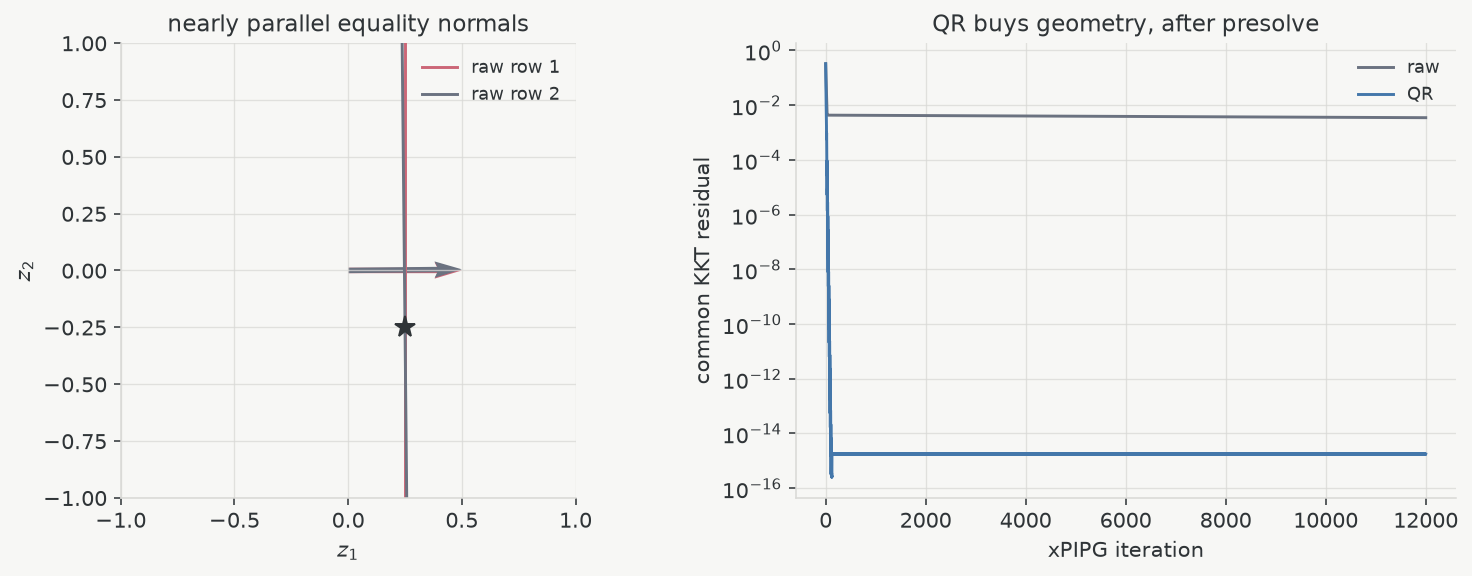

In [35]:
blue, orange, gray, dark, grid = (
    "#4477AA", "#CC6677", "#6B7280", "#2F3437", "#D9D9D6")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), dpi=140,
                         layout="constrained")
xgrid = np.linspace(-1, 1, 200)
for row, rhs, color, label in zip(
        A_parallel["G"], A_parallel["g"],
        (orange, gray), ("raw row 1", "raw row 2")):
    if abs(row[1]) > 1e-12:
        axes[0].plot(xgrid, (rhs - row[0] * xgrid) / row[1],
                     color=color, label=label)
    else:
        axes[0].axvline(rhs / row[0], color=color, label=label)
axes[0].plot(*A_parallel["z_star"], marker="*", ms=11, color=dark)
axes[0].quiver(
    [0, 0], [0, 0], A_parallel["G"][:, 0], A_parallel["G"][:, 1],
    angles="xy", scale_units="xy", scale=2.0,
    color=[orange, gray], width=0.012)
axes[0].set(xlim=(-1, 1), ylim=(-1, 1), xlabel=r"$z_1$",
            ylabel=r"$z_2$", title="nearly parallel equality normals")
axes[0].set_aspect("equal")
axes[0].legend(frameon=False)

axes[1].semilogy(
    np.maximum(np.max(run_A2_raw["diagnostics"][:, 1:], axis=1), 1e-16),
    color=gray, label="raw")
axes[1].semilogy(
    np.maximum(np.max(run_A2_qr["diagnostics"][:, 1:], axis=1), 1e-16),
    color=blue, label="QR")
axes[1].set(xlabel="xPIPG iteration", ylabel="common KKT residual",
            title="QR buys geometry, after presolve")
axes[1].legend(frameon=False)
finish_axes(axes, grid)
plt.show()

#### Dense whitening and projection cost

Let $P=R^\top R$ and introduce the whitened variable $y=Rx_{\mathrm{phys}}$.
The quadratic Hessian becomes the identity, but the primal set becomes

$$
D_y=R D_{\mathrm{phys}}.
$$

For dense $R$, an axis-aligned box is generally mapped to a rotated
parallelogram or parallelotope. Clipping the coordinatewise bounds of that
image is not $\Pi_{D_y}$. The next calculation compares the two projections
directly. It isolates the principal limitation of arbitrary Hessian whitening:
improved curvature is not useful if it converts a closed-form primal projection
into another optimization problem.

In [36]:
# Negative off-diagonal makes the two coordinate-wise maxima come from
# different physical box corners, so the bounding-box corner is infeasible.
P_dense_warning = np.array([[2.0, -1.0], [-1.0, 2.0]])
R_warning = np.linalg.cholesky(P_dense_warning).T
corners = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]], float)
transformed_corners = corners @ R_warning.T
query = transformed_corners.max(axis=0)
naive = np.clip(
    query, transformed_corners.min(axis=0), transformed_corners.max(axis=0))

x_proj = cp.Variable(2)
true_problem = cp.Problem(
    cp.Minimize(cp.sum_squares(R_warning @ x_proj - query)),
    [x_proj >= -1.0, x_proj <= 1.0])
true_problem.solve(solver="CLARABEL", tol_gap_abs=1e-11, tol_feas=1e-11)
true_projection = R_warning @ np.asarray(x_proj.value)
projection_warning_error = np.linalg.norm(naive - true_projection)

print(f"query              {query}")
print(f"bounding-box clip   {naive}")
print(f"true projection     {true_projection}")
print(f"projection error    {projection_warning_error:.6f}")
try:
    hypersphere_precondition_compatible(
        P_dense_warning, np.zeros(2), np.eye(2), np.zeros(2),
        -np.ones(2), np.ones(2), n_zero=2)
except ValueError as exc:
    print(f"dense whitening rejected: {exc}")
else:
    raise AssertionError("dense whitening must be rejected")
assert projection_warning_error > 1e-3

query              [2.12132034 1.22474487]
bounding-box clip   [2.12132034 1.22474487]
true projection     [1.06066017 0.61237244]
projection error    1.224745
dense whitening rejected: dense whitening would destroy this box projection


#### Eight representations of one trajectory QP

The same physical equality-constrained trajectory QP is expressed in eight
ways: raw coordinates; scalar primal/dual step-ratio tuning; modified Ruiz
equilibration; QR equality preconditioning; diagonal hypersphere whitening;
constraint row normalization; objective scalar normalization; and the
compatible combination of whitening, row normalization, and objective scaling.

These operations act on different objects. Step-ratio tuning changes the
algorithmic metric without changing coordinates. Ruiz scales primal and
constraint coordinates iteratively. QR mixes only equality rows. Hypersphere
preconditioning changes the primal coordinate, while objective scaling changes
the relative primal--dual scale and the multiplier normalization. Treating them
as interchangeable scalar tuning would obscure the mechanism being measured.

All eight runs use the same physical KKT test after inverse primal and dual
maps. Their iteration counts are therefore comparable even though the internal
residuals and multipliers have different scales.

In [37]:
raw_B = identity_transform(B)

# Scalar ratio tuning changes beta/alpha without changing coordinates.
ratio_grid = np.array([0.1, 0.3, 1.0, 3.0, 10.0])
ratio_runs = [
    run_equality_variant(
        f"raw ratio {ratio:g}", B, raw_B,
        ratio=ratio, rho_relax=1.6, steps=4000)
    for ratio in ratio_grid
]
scalar_run = min(
    ratio_runs,
    key=lambda r: 10**9 if r["iterations"] is None else r["iterations"])
scalar_run = dict(scalar_run)
scalar_run["name"] = f"scalar ratio={scalar_run['ratio']:g}"

# Coordinate and row transformations define distinct representations.
ruiz_B = ruiz_equilibrate(
    B["P"], B["q"], B["G"], B["g_eq"], B["lower"], B["upper"],
    n_zero=B["G"].shape[0], sweeps=6)

t0_qr = time.perf_counter_ns()
H_qr_B, g_qr_B, E_qr_B, eta_B = qr_precondition_equalities(
    B["P"], B["G"], B["g_eq"])
qr_setup_ms = (time.perf_counter_ns() - t0_qr) / 1e6
qr_B = dict(
    P=B["P"].copy(), q=B["q"].copy(), H=H_qr_B, g=g_qr_B,
    lower=B["lower"].copy(), upper=B["upper"].copy(),
    D=np.eye(B["n"]), E=E_qr_B, c=1.0)

white_B = hypersphere_precondition_compatible(
    B["P"], B["q"], B["G"], B["g_eq"], B["lower"], B["upper"],
    n_zero=B["G"].shape[0], row_normalize=False, objective_scale=False)

E_row_B = block_row_normalizer(
    B["G"], B["g_eq"], B["G"].shape[0], 0)
row_B = dict(
    P=B["P"].copy(), q=B["q"].copy(),
    H=E_row_B @ B["G"], g=E_row_B @ B["g_eq"],
    lower=B["lower"].copy(), upper=B["upper"].copy(),
    D=np.eye(B["n"]), E=E_row_B, c=1.0)

objective_c = 1.0 / np.linalg.norm(B["P"], 2)
objective_B = identity_transform(B, objective_scale=objective_c)

# Combine only transforms that preserve the diagonal-box structure.
complete_B = hypersphere_precondition_compatible(
    B["P"], B["q"], B["G"], B["g_eq"], B["lower"], B["upper"],
    n_zero=B["G"].shape[0], row_normalize=True, objective_scale=True)

variants = [
    run_equality_variant("raw", B, raw_B, ratio=1.0, steps=5000),
    scalar_run,
    run_equality_variant("modified Ruiz", B, ruiz_B, ratio=1.0, steps=5000),
    run_equality_variant("QR equalities", B, qr_B, ratio=1.0, steps=5000),
    run_equality_variant("whitening only", B, white_B, ratio=1.0, steps=5000),
    run_equality_variant("row normalization only", B, row_B,
                         ratio=1.0, steps=5000),
    run_equality_variant("objective scalar only", B, objective_B,
                         ratio=1.0, steps=5000),
    run_equality_variant(
        "complete compatible", B, complete_B,
        ratio=complete_B["omega_sqrt_ratio"]**2, steps=5000),
]

print(f"{'variant':<25} {'iters':>7} {'final KKT':>11} "
      f"{'KKT cond':>12} {'density':>9} {'alpha':>10} {'beta/alpha':>11}")
for result in variants:
    print(f"{result['name']:<25} {str(result['iterations']):>7} "
          f"{result['final_kkt']:>11.2e} {result['condition']:>12.3e} "
          f"{result['density']:>9.3f} {result['alpha']:>10.3e} "
          f"{result['ratio']:>11.3g}")

print(f"\nQR presolve: {qr_setup_ms:.3f} ms; "
      f"operator density {np.count_nonzero(B['G'])/B['G'].size:.3f} "
      f"-> {np.count_nonzero(H_qr_B)/H_qr_B.size:.3f}")
print("complete hypersphere:",
      f"sigma_min={complete_B['sigma_min']:.3e}, "
      f"lambda*={complete_B['c']:.3e}, "
      f"sqrt step ratio={complete_B['omega_sqrt_ratio']:.3e}")

variant                     iters   final KKT     KKT cond   density      alpha  beta/alpha
raw                          1395    9.50e-16    1.988e+02     0.067  9.496e-02           1
scalar ratio=3                853    5.29e-16    1.988e+02     0.067  8.847e-02           3
modified Ruiz                 184    5.44e-16    1.154e+01     0.067  4.783e-01           1
QR equalities                 886    1.18e-15    1.976e+02     0.288  9.851e-02           1
whitening only                357    5.99e-16    2.806e+01     0.067  1.436e-01           1
row normalization only       1693    1.94e-15    1.978e+02     0.067  9.696e-02           1
objective scalar only        1864    4.32e-11    4.214e+02     0.067  3.714e-01           1
complete compatible           130    4.53e-16    9.422e+00     0.067  5.889e-01           1

QR presolve: 0.562 ms; operator density 0.067 -> 0.288
complete hypersphere: sigma_min=6.367e-02, lambda*=1.784e-01, sqrt step ratio=1.000e+00


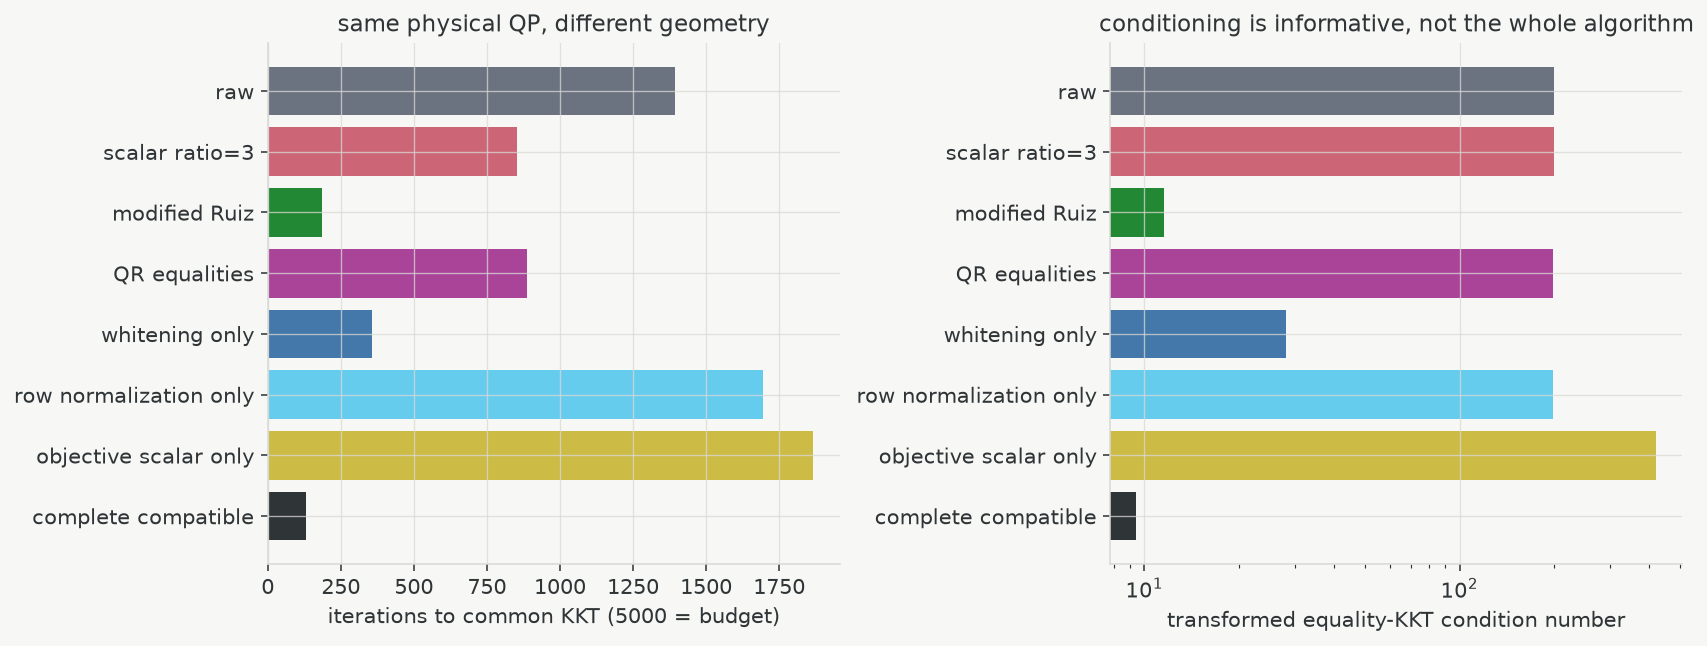

In [38]:
blue, orange, green, purple, gray, dark, grid = (
    "#4477AA", "#CC6677", "#228833", "#AA4499",
    "#6B7280", "#2F3437", "#D9D9D6")

labels = [r["name"] for r in variants]
iterations_plot = [
    5000 if r["iterations"] is None else r["iterations"] for r in variants]
conditions_plot = [r["condition"] for r in variants]
colors = [gray, orange, green, purple, blue, "#66CCEE", "#CCBB44", dark]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140,
                         layout="constrained")
ypos = np.arange(len(labels))
axes[0].barh(ypos, iterations_plot, color=colors)
axes[0].set_yticks(ypos, labels)
axes[0].invert_yaxis()
axes[0].set(xlabel="iterations to common KKT (5000 = budget)",
            title="same physical QP, different geometry")

axes[1].barh(ypos, conditions_plot, color=colors)
axes[1].set_yticks(ypos, labels)
axes[1].invert_yaxis()
axes[1].set_xscale("log")
axes[1].set(xlabel="transformed equality-KKT condition number",
            title="conditioning is informative, not the whole algorithm")
finish_axes(axes, grid)
plt.show()

#### Projection structure under transformation

| Transformation | Box projection | Zero cone | Orthant | SOC | Scope used here |
|---|---|---|---|---|---|
| objective scalar | unchanged | unchanged | unchanged | unchanged | unrestricted positive scalar |
| positive diagonal primal scale | rescaled box, still clipping | unchanged | unchanged | requires compatible block action through $H$ | diagonal case checked |
| positive row scale | unchanged | preserved | sign preserved | one common scalar per SOC block | cone-compatible blocks |
| QR row mixing | unchanged | preserved within equality rows | generally not preserved | not preserved | full-row-rank equalities only |
| dense primal whitening | rotated set | unchanged | depends on transformed operator | only for cone automorphisms | rejected for a generic box |
| diagonal primal whitening | rescaled box, still clipping | unchanged | positive scales remain simple | block compatibility still required | compatible case used |

The conic row normalizer consequently applies one common scalar to all three
rows of each SOC block. Independent scaling inside an SOC would change the cone
rather than merely its coordinates.

In [39]:
# Verify that row normalization acts by one scalar on each SOC block.
E_conic_audit = block_row_normalizer(
    C_feas["H"], C_feas["g"], C_feas["n_zero"], C_feas["n_soc"])
soc_scales = np.diag(E_conic_audit)[C_feas["n_zero"]:].reshape(-1, 3)
within_block_spread = np.max(np.ptp(soc_scales, axis=1))
assert np.allclose(soc_scales, soc_scales[:, :1])
print(f"SOC blocks={len(soc_scales)} | "
      f"scale={soc_scales[0, 0]:.6f} | "
      f"max within-block spread={within_block_spread:.1e}")

SOC blocks=8 | scale=0.833333 | max within-block spread=0.0e+00


**Observation.** Preconditioning is beneficial only when it improves
the geometry without destroying the inexpensive operators on which the
first-order iteration relies. QR is an equality-specific exchange of offline
factorization and denser products for orthogonal constraint normals. The
hypersphere construction is compatible with the trajectory box because its
$P$ is diagonal. The dense counterexample shows why this compatibility cannot
be inferred from improved Hessian conditioning alone.

### Synthesis — offline and online work

| Cost category | splitQP ADMM | xPIPG |
|---|---|---|
| setup | form and factor $P+\sigma I+A^\top R A$ | estimate norms and, when selected, equilibrate, compute a QR factorization, or construct a whitening map |
| compilation | compile the JAX solve or sequence program | compile the JAX iteration or sequence program |
| online iteration | apply $A^\top$ and $A$, clip once, perform two triangular solves | apply $P$, $H$, and $H^\top$, then project onto the primal set and polar cone |
| native diagnostics | ADMM primal and dual residuals | KKT and displacement quantities |
| timed comparison | common KKT residual in physical coordinates | the same residual |
| reference solve | excluded | excluded |

Both timed methods stop when

$$
\max(r_{\mathrm{pri}},r_{\mathrm{stat}},r_{\mathrm{cone}})
\le 10^{-5}.
$$

The ADMM adapter calls the unchanged `splitqp.step` with its cached factor and
replaces only the package stopping report by this common residual. xPIPG
evaluates the same residual inside its loop. Diagnostic work is therefore
included symmetrically. Compilation is warmed before online timing, while setup
and first-call compilation remain separately reported.

In [40]:
COMMON_TIMING_TOL = 1e-5
TIMING_MAX_ITER = 10000
TRACE_STEPS_FOR_MEMORY = 5000

# Common original-coordinate stop around the unchanged ADMM kernel.
@partial(jax.jit, static_argnames=("max_iter",))
def run_splitqp_equality_to_tol(
        cache, q, l, u, G, g, lower, upper, state0,
        tolerance, max_iter):
    def condition(carry):
        state, iteration = carry
        diagnostics = conic_diagnostics_one(
            cache.P, q, G, g, lower, upper,
            state.x, state.y[:G.shape[0]], G.shape[0], 0, 0)
        return ((iteration < max_iter)
                & (jnp.max(diagnostics[1:]) > tolerance))

    def body(carry):
        state, iteration = carry
        return splitqp_step(cache, q, l, u, state), iteration + 1

    return jax.lax.while_loop(
        condition, body, (state0, jnp.asarray(0, dtype=jnp.int32)))

@partial(jax.jit, static_argnames=("max_iter",))
def run_splitqp_equality_sequence_to_tol(
        cache, qs, ls, us, G, g, lower, upper, state0,
        tolerance, max_iter):
    def member(state, member_data):
        q, l, u = member_data

        def condition(carry):
            current, iteration = carry
            diagnostics = conic_diagnostics_one(
                cache.P, q, G, g, lower, upper,
                current.x, current.y[:G.shape[0]], G.shape[0], 0, 0)
            return ((iteration < max_iter)
                    & (jnp.max(diagnostics[1:]) > tolerance))

        def body(carry):
            current, iteration = carry
            return (splitqp_step(cache, q, l, u, current),
                    iteration + 1)

        state, iterations = jax.lax.while_loop(
            condition, body,
            (state, jnp.asarray(0, dtype=jnp.int32)))
        return state, (state, iterations)
    return jax.lax.scan(member, state0, (qs, ls, us))

# The same stop around the xPIPG kernel.
@partial(jax.jit, static_argnames=("max_iter",))
def run_xpipg_equality_to_tol(P, q, H, g, lower, upper,
                              alpha, beta, rho_relax, state0,
                              tolerance, max_iter):
    data = ConicData(P, q, H, g, lower, upper, alpha, beta)

    def condition(carry):
        state, iteration = carry
        diagnostics = conic_diagnostics_one(
            P, q, H, g, lower, upper, state.z, state.w,
            H.shape[0], 0, 0)
        return ((iteration < max_iter)
                & (jnp.max(diagnostics[1:]) > tolerance))

    def body(carry):
        state, iteration = carry
        state = xpipg_step(data, state, rho_relax, H.shape[0], 0, 0)
        return state, iteration + 1

    return jax.lax.while_loop(
        condition, body, (state0, jnp.asarray(0, dtype=jnp.int32)))

@partial(jax.jit, static_argnames=("max_iter",))
def run_xpipg_equality_sequence_to_tol(
        P, qs, H, g, lower, upper, alpha, beta, rho_relax, state0,
        tolerance, max_iter):
    def member(state, q):
        data = ConicData(P, q, H, g, lower, upper, alpha, beta)

        def condition(carry):
            current, iteration = carry
            diagnostics = conic_diagnostics_one(
                P, q, H, g, lower, upper, current.z, current.w,
                H.shape[0], 0, 0)
            return ((iteration < max_iter)
                    & (jnp.max(diagnostics[1:]) > tolerance))

        def body(carry):
            current, iteration = carry
            current = xpipg_step(
                data, current, rho_relax, H.shape[0], 0, 0)
            return current, iteration + 1

        state, iterations = jax.lax.while_loop(
            condition, body,
            (state, jnp.asarray(0, dtype=jnp.int32)))
        return state, (state, iterations)
    return jax.lax.scan(member, state0, qs)

# Fixed-shape target family used in the amortization experiment.
def make_target_family(count=128, dt=0.25):
    targets = np.column_stack((
        np.linspace(0.5, 1.1, count),
        np.linspace(0.25, 0.55, count)))
    qs = np.stack([
        make_mpc_problem(target=target, dt=dt, hard_terminal=False)["q"]
        for target in targets])
    return targets, qs

t0 = time.perf_counter_ns()
targets_family, qs_family = make_target_family()
family_data_construction = (time.perf_counter_ns() - t0) / 1e6
alpha_seq, beta_seq, _, _, _ = safe_xpipg_steps(
    B["P"], B["G"], beta_over_alpha=1.0)
state0_seq = XPIPGState(
    project_box(jnp.zeros(B["n"]), jnp.asarray(B["lower"]),
                jnp.asarray(B["upper"])),
    jnp.zeros(B["G"].shape[0]),
    project_box(jnp.zeros(B["n"]), jnp.asarray(B["lower"]),
                jnp.asarray(B["upper"])),
    jnp.zeros(B["G"].shape[0]))

#### Regime 1: changing matrices

Changing $\Delta t$ preserves array shapes but changes the dynamics matrix.
splitQP must construct and factor a new system for each member. xPIPG reuses the
compiled shape but repeats operator-norm estimation and step selection. The
experiment reports data construction, method-specific setup, synchronized
online time, iterations, and final physical-coordinate KKT residual separately.
It therefore compares refactorization with explicit setup rather than charging
only one method for changing data.

In [41]:
changing_rows = []
# Compile both fixed-shape paths before timing.
warm_problem = make_mpc_problem(dt=0.25, hard_terminal=False)
warm_A = np.vstack((warm_problem["G"], np.eye(warm_problem["n"])))
warm_l = np.concatenate((warm_problem["g_eq"], warm_problem["lower"]))
warm_u = np.concatenate((warm_problem["g_eq"], warm_problem["upper"]))
warm_solver = splitqp.Solver(warm_problem["P"], warm_A)
block(warm_solver.cache.factor)
warm_admm_state0 = ADMMState(
    jnp.zeros(warm_problem["n"]), jnp.zeros(warm_A.shape[0]),
    jnp.zeros(warm_A.shape[0]))
warm_admm_state, _ = run_splitqp_equality_to_tol(
    warm_solver.cache, *map(jnp.asarray, (
        warm_problem["q"], warm_l, warm_u, warm_problem["G"],
        warm_problem["g_eq"], warm_problem["lower"],
        warm_problem["upper"])),
    warm_admm_state0, jnp.asarray(COMMON_TIMING_TOL),
    max_iter=TIMING_MAX_ITER)
block(warm_admm_state.x)
warm_x_state, _ = run_xpipg_equality_to_tol(
    *map(jnp.asarray, (
        warm_problem["P"], warm_problem["q"], warm_problem["G"],
        warm_problem["g_eq"], warm_problem["lower"],
        warm_problem["upper"])),
    jnp.asarray(alpha_seq), jnp.asarray(beta_seq), jnp.asarray(1.6),
    state0_seq, jnp.asarray(COMMON_TIMING_TOL),
    max_iter=TIMING_MAX_ITER)
block(warm_x_state.z)

for dt_value in (0.20, 0.225, 0.25, 0.275, 0.30):
    # Build the new matrix data.
    t0 = time.perf_counter_ns()
    problem = make_mpc_problem(dt=dt_value, hard_terminal=False)
    data_construction = (time.perf_counter_ns() - t0) / 1e6
    A_split_dt = np.vstack((problem["G"], np.eye(problem["n"])))
    l_dt = np.concatenate((problem["g_eq"], problem["lower"]))
    u_dt = np.concatenate((problem["g_eq"], problem["upper"]))

    # Factor and run the ADMM kernel.
    t0 = time.perf_counter_ns()
    solver = splitqp.Solver(problem["P"], A_split_dt)
    block(solver.cache.factor)
    admm_setup = (time.perf_counter_ns() - t0) / 1e6
    state0_admm_dt = ADMMState(
        jnp.zeros(problem["n"]), jnp.zeros(A_split_dt.shape[0]),
        jnp.zeros(A_split_dt.shape[0]))
    _, admm_online, _ = timed(
        lambda: run_splitqp_equality_to_tol(
            solver.cache, *map(jnp.asarray, (
                problem["q"], l_dt, u_dt, problem["G"],
                problem["g_eq"], problem["lower"], problem["upper"])),
            state0_admm_dt, jnp.asarray(COMMON_TIMING_TOL),
            max_iter=TIMING_MAX_ITER)[0].x,
        repeats=3)
    final_admm_dt, admm_iterations = run_splitqp_equality_to_tol(
        solver.cache, *map(jnp.asarray, (
            problem["q"], l_dt, u_dt, problem["G"],
            problem["g_eq"], problem["lower"], problem["upper"])),
        state0_admm_dt, jnp.asarray(COMMON_TIMING_TOL),
        max_iter=TIMING_MAX_ITER)
    w_eq = np.asarray(
        final_admm_dt.y[:problem["G"].shape[0]])
    admm_diag = np.asarray(conic_diagnostics_one(
        *map(jnp.asarray, (
            problem["P"], problem["q"], problem["G"], problem["g_eq"],
            problem["lower"], problem["upper"],
            final_admm_dt.x, w_eq)),
        n_zero=problem["G"].shape[0], n_nonnegative=0, n_soc=0))

    # Estimate the norm, select steps, and run xPIPG.
    t0 = time.perf_counter_ns()
    norm_setup = estimate_operator_norm(problem["G"])
    alpha_dt, beta_dt, _, _, _ = safe_xpipg_steps(
        problem["P"], problem["G"], 1.0,
        norm_H_override=norm_setup["norm"])
    pipg_setup = (time.perf_counter_ns() - t0) / 1e6
    _, pipg_online, _ = timed(
        lambda: run_xpipg_equality_to_tol(
            *map(jnp.asarray, (
                problem["P"], problem["q"], problem["G"],
                problem["g_eq"], problem["lower"], problem["upper"])),
            jnp.asarray(alpha_dt), jnp.asarray(beta_dt),
            jnp.asarray(1.6), state0_seq,
            jnp.asarray(COMMON_TIMING_TOL),
            max_iter=TIMING_MAX_ITER)[0].z,
        repeats=3)
    final_state_dt, pipg_iterations = run_xpipg_equality_to_tol(
        *map(jnp.asarray, (
            problem["P"], problem["q"], problem["G"],
            problem["g_eq"], problem["lower"], problem["upper"])),
        jnp.asarray(alpha_dt), jnp.asarray(beta_dt), jnp.asarray(1.6),
        state0_seq, jnp.asarray(COMMON_TIMING_TOL),
        max_iter=TIMING_MAX_ITER)
    pipg_diag = np.asarray(conic_diagnostics_one(
        *map(jnp.asarray, (
            problem["P"], problem["q"], problem["G"], problem["g_eq"],
            problem["lower"], problem["upper"],
            final_state_dt.z, final_state_dt.w)),
        n_zero=problem["G"].shape[0], n_nonnegative=0, n_soc=0))

    changing_rows.append(dict(
        dt=dt_value, data=data_construction,
        admm_setup=admm_setup, admm_online=admm_online,
        pipg_setup=pipg_setup, pipg_online=pipg_online,
        admm_kkt=float(np.max(admm_diag[1:])),
        pipg_kkt=float(np.max(pipg_diag[1:])),
        admm_iterations=int(np.asarray(admm_iterations)),
        pipg_iterations=int(np.asarray(pipg_iterations)),
        norm_matvecs=2 * norm_setup["iterations"]))

assert max(row["admm_kkt"] for row in changing_rows) <= COMMON_TIMING_TOL
assert max(row["pipg_kkt"] for row in changing_rows) <= COMMON_TIMING_TOL
print(f"{'dt':>5} {'data ms':>8} {'A setup':>9} {'A online':>9} "
      f"{'x setup':>10} {'x online':>10} "
      f"{'ADMM KKT':>9} {'xPIPG KKT':>9} {'A iter':>7} {'x iter':>7}")
for row in changing_rows:
    print(f"{row['dt']:>5.3f} {row['data']:>8.3f} "
          f"{row['admm_setup']:>9.3f} {row['admm_online']:>9.3f} "
          f"{row['pipg_setup']:>10.3f} {row['pipg_online']:>10.3f} "
          f"{row['admm_kkt']:>9.1e} {row['pipg_kkt']:>9.1e} "
          f"{row['admm_iterations']:>7} {row['pipg_iterations']:>7}")

   dt  data ms   A setup  A online    x setup   x online  ADMM KKT xPIPG KKT  A iter  x iter
0.200    0.164     1.861     6.866      0.718      2.667   1.0e-05   1.0e-05    1451    1271
0.225    0.104     2.011     6.335      0.673      2.574   9.9e-06   9.9e-06    1106    1223
0.250    0.109     1.702     3.373      0.647      3.154   9.9e-06   9.9e-06     685    1141
0.275    0.094     1.366     3.358      0.645      2.853   9.9e-06   9.8e-06     539     977
0.300    0.092     2.554     1.903      0.663      2.882   9.9e-06   1.0e-05     343     983


#### Regime 2: a fixed-matrix family

This regime matches splitQP's principal design assumption: $P$ and $A$ are fixed
while nearby targets change $q$. Consecutive members warm-start from the
previous terminal state. ADMM reuses one factorization; xPIPG reuses its norm
estimate, step sizes, and compiled operator program.

The public `solve_sequence` follows the same ordered warm-start pattern. To use
the common KKT stopping rule, both kernels are placed in a `lax.scan` with the
same member order. Each prefix shape is compiled and synchronized before timing.
The deployed cumulative cost is

$$
T(B)=T_{\mathrm{setup}}+T_{\mathrm{online}}(B),
$$

where compilation is shown separately rather than hidden in either term. The
family-size curve is consequently an empirical amortization comparison, not an
iteration-count proxy for runtime.

In [42]:
PREFIXES = (1, 4, 16, 64, 128)

# Measure setup once for each fixed operator.
setup_samples = []
for _ in range(5):
    t0 = time.perf_counter_ns()
    setup_solver = splitqp.Solver(B["P"], A_B_split)
    block(setup_solver.cache.factor)
    setup_samples.append((time.perf_counter_ns() - t0) / 1e6)
admm_family_setup = float(np.median(setup_samples))

t0 = time.perf_counter_ns()
norm_family = estimate_operator_norm(B["G"])
alpha_family, beta_family, _, _, _ = safe_xpipg_steps(
    B["P"], B["G"], 1.0, norm_H_override=norm_family["norm"])
xpipg_family_setup = (time.perf_counter_ns() - t0) / 1e6

# Compile and time each ordered family shape.
family_rows = []
for prefix in PREFIXES:
    qs = jnp.asarray(qs_family[:prefix])
    l_family = np.broadcast_to(l_B_split, (prefix, len(l_B_split)))
    u_family = np.broadcast_to(u_B_split, (prefix, len(u_B_split)))

    solver = splitqp.Solver(B["P"], A_B_split)
    state0_admm_family = ADMMState(
        jnp.zeros(B["n"]), jnp.zeros(A_B_split.shape[0]),
        jnp.zeros(A_B_split.shape[0]))
    # First synchronized call compiles this prefix shape.
    t0 = time.perf_counter_ns()
    warm_admm = run_splitqp_equality_sequence_to_tol(
        solver.cache, qs, jnp.asarray(l_family), jnp.asarray(u_family),
        jnp.asarray(B["G"]), jnp.asarray(B["g_eq"]),
        jnp.asarray(B["lower"]), jnp.asarray(B["upper"]),
        state0_admm_family, jnp.asarray(COMMON_TIMING_TOL),
        max_iter=TIMING_MAX_ITER)
    block(warm_admm[1][0].x)
    admm_compile = (time.perf_counter_ns() - t0) / 1e6
    _, admm_online, admm_iqr = timed(
        lambda: run_splitqp_equality_sequence_to_tol(
            solver.cache, qs, jnp.asarray(l_family),
            jnp.asarray(u_family), jnp.asarray(B["G"]),
            jnp.asarray(B["g_eq"]), jnp.asarray(B["lower"]),
            jnp.asarray(B["upper"]), state0_admm_family,
            jnp.asarray(COMMON_TIMING_TOL),
            max_iter=TIMING_MAX_ITER)[1][0].x,
        repeats=3)
    _, (admm_states, admm_iterations) = (
        run_splitqp_equality_sequence_to_tol(
            solver.cache, qs, jnp.asarray(l_family),
            jnp.asarray(u_family), jnp.asarray(B["G"]),
            jnp.asarray(B["g_eq"]), jnp.asarray(B["lower"]),
            jnp.asarray(B["upper"]), state0_admm_family,
            jnp.asarray(COMMON_TIMING_TOL),
            max_iter=TIMING_MAX_ITER))

    # Compile and time the xPIPG sequence with the same warm starts.
    t0 = time.perf_counter_ns()
    warm_x = run_xpipg_equality_sequence_to_tol(
        jnp.asarray(B["P"]), qs, jnp.asarray(B["G"]),
        jnp.asarray(B["g_eq"]), jnp.asarray(B["lower"]),
        jnp.asarray(B["upper"]), jnp.asarray(alpha_family),
        jnp.asarray(beta_family), jnp.asarray(1.6), state0_seq,
        jnp.asarray(COMMON_TIMING_TOL), max_iter=TIMING_MAX_ITER)
    block(warm_x[1][0].z)
    xpipg_compile = (time.perf_counter_ns() - t0) / 1e6
    _, xpipg_online, xpipg_iqr = timed(
        lambda: run_xpipg_equality_sequence_to_tol(
            jnp.asarray(B["P"]), qs, jnp.asarray(B["G"]),
            jnp.asarray(B["g_eq"]), jnp.asarray(B["lower"]),
            jnp.asarray(B["upper"]), jnp.asarray(alpha_family),
            jnp.asarray(beta_family), jnp.asarray(1.6), state0_seq,
            jnp.asarray(COMMON_TIMING_TOL),
            max_iter=TIMING_MAX_ITER)[1][0].z,
        repeats=3)
    _, (xpipg_states, xpipg_iterations) = (
        run_xpipg_equality_sequence_to_tol(
        jnp.asarray(B["P"]), qs, jnp.asarray(B["G"]),
        jnp.asarray(B["g_eq"]), jnp.asarray(B["lower"]),
        jnp.asarray(B["upper"]), jnp.asarray(alpha_family),
        jnp.asarray(beta_family), jnp.asarray(1.6), state0_seq,
        jnp.asarray(COMMON_TIMING_TOL), max_iter=TIMING_MAX_ITER))

    # Common original-unit quality, worst family member.
    x_diag = []
    a_diag = []
    for i in range(prefix):
        x_diag.append(np.asarray(conic_diagnostics_one(
            *map(jnp.asarray, (
                B["P"], qs_family[i], B["G"], B["g_eq"],
                B["lower"], B["upper"],
                xpipg_states.z[i], xpipg_states.w[i])),
            n_zero=B["G"].shape[0], n_nonnegative=0, n_soc=0)))
        a_diag.append(np.asarray(conic_diagnostics_one(
            *map(jnp.asarray, (
                B["P"], qs_family[i], B["G"], B["g_eq"],
                B["lower"], B["upper"], admm_states.x[i],
                admm_states.y[i, :B["G"].shape[0]])),
            n_zero=B["G"].shape[0], n_nonnegative=0, n_soc=0)))
    family_rows.append(dict(
        B=prefix,
        admm_online=admm_online, xpipg_online=xpipg_online,
        admm_compile=admm_compile, xpipg_compile=xpipg_compile,
        admm_iqr=admm_iqr, xpipg_iqr=xpipg_iqr,
        admm_kkt=float(np.max(np.asarray(a_diag)[:, 1:])),
        xpipg_kkt=float(np.max(np.asarray(x_diag)[:, 1:])),
        admm_iterations=int(np.sum(np.asarray(admm_iterations))),
        xpipg_iterations=int(np.sum(np.asarray(xpipg_iterations))),
    ))

assert max(row["admm_kkt"] for row in family_rows) <= COMMON_TIMING_TOL
assert max(row["xpipg_kkt"] for row in family_rows) <= COMMON_TIMING_TOL
print(f"family data construction: {family_data_construction:.3f} ms")
print(f"ADMM factor/setup median: {admm_family_setup:.3f} ms")
print(f"xPIPG norm/step setup:    {xpipg_family_setup:.3f} ms "
      f"({2*norm_family['iterations']} setup matvecs)")
print(f"{'B':>4} {'ADMM ms':>10} {'xPIPG ms':>10} "
      f"{'ADMM KKT':>11} {'xPIPG KKT':>11} "
      f"{'ADMM iters':>11} {'xPIPG iters':>12}")
for row in family_rows:
    print(f"{row['B']:>4} {row['admm_online']:>10.3f} "
          f"{row['xpipg_online']:>10.3f} {row['admm_kkt']:>11.2e} "
          f"{row['xpipg_kkt']:>11.2e} {row['admm_iterations']:>11} "
          f"{row['xpipg_iterations']:>12}")

family data construction: 4.697 ms
ADMM factor/setup median: 1.238 ms
xPIPG norm/step setup:    0.730 ms (200 setup matvecs)
   B    ADMM ms   xPIPG ms    ADMM KKT   xPIPG KKT  ADMM iters  xPIPG iters
   1      3.067      3.052    9.84e-06    9.82e-06         429          978
   4      6.232      6.198    9.84e-06    9.96e-06        1047         2351
  16     19.534     20.192    9.84e-06    9.96e-06        3519         7847
  64     58.087     54.012    9.84e-06    9.96e-06       13407        29831
 128    142.141    114.502    1.00e-05    9.96e-06       33061        63780


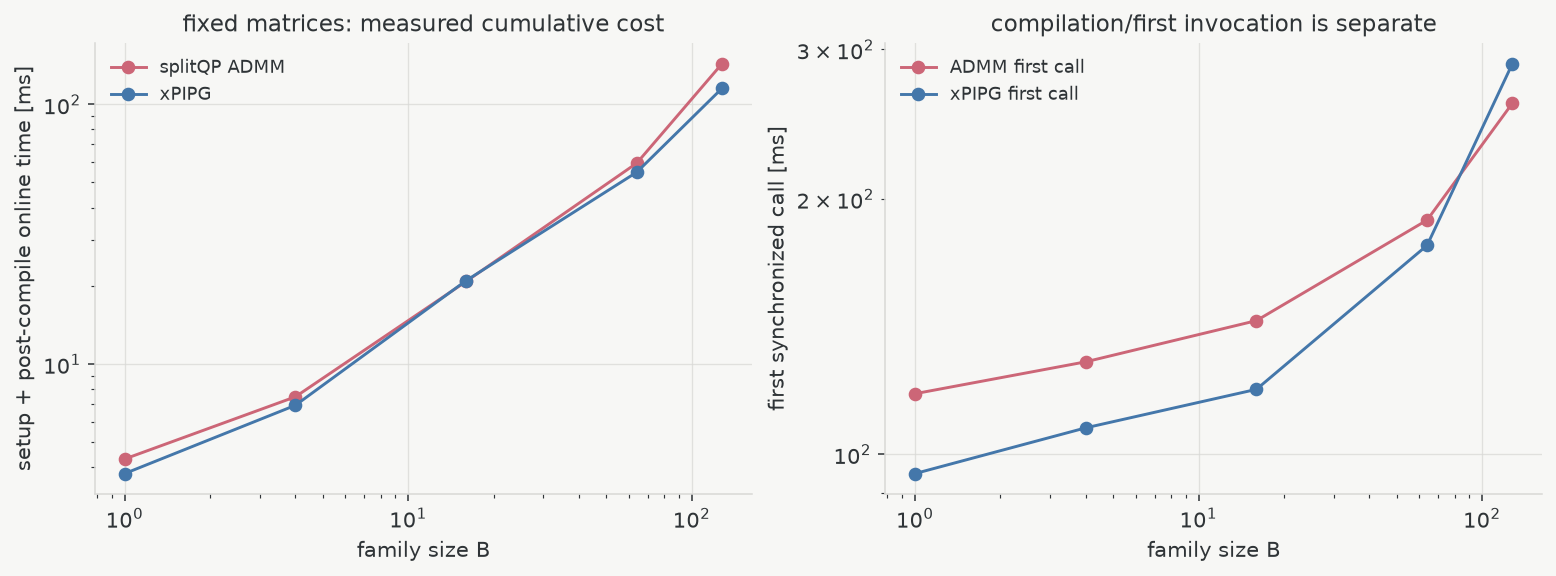

In [43]:
blue, orange, grid = "#4477AA", "#CC6677", "#D9D9D6"

Bvals = np.array([row["B"] for row in family_rows])
admm_cumulative = np.array([
    admm_family_setup + row["admm_online"] for row in family_rows])
xpipg_cumulative = np.array([
    xpipg_family_setup + row["xpipg_online"] for row in family_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), dpi=140,
                         layout="constrained")
axes[0].plot(Bvals, admm_cumulative, marker="o", color=orange,
             label="splitQP ADMM")
axes[0].plot(Bvals, xpipg_cumulative, marker="o", color=blue,
             label="xPIPG")
axes[0].set(xscale="log", yscale="log", xlabel="family size B",
            ylabel="setup + post-compile online time [ms]",
            title="fixed matrices: measured cumulative cost")
axes[0].legend(frameon=False)

axes[1].plot(Bvals, [row["admm_compile"] for row in family_rows],
             marker="o", color=orange, label="ADMM first call")
axes[1].plot(Bvals, [row["xpipg_compile"] for row in family_rows],
             marker="o", color=blue, label="xPIPG first call")
axes[1].set(xscale="log", yscale="log", xlabel="family size B",
            ylabel="first synchronized call [ms]",
            title="compilation/first invocation is separate")
axes[1].legend(frameon=False)
finish_axes(axes, grid)
plt.show()

#### Iterations, operators, and persistent state

| Method | Recurring work per iteration | Persistent state beyond problem data |
|---|---|---|
| splitQP ADMM | $A^\top$, $A$, one interval projection, two triangular solves | $x,s,y$ (stored as `State.x`, `State.z`, `State.y`) and a Cholesky factor |
| cached PIPGeq | $P$, $G$, $G^\top$, one projection onto $Z$ | $z,w,Gz-g$ |
| xPIPG | $P$, $H$, $H^\top$, projections onto $D$ and $K^\circ$ | $\xi,\eta,z,w$ |

The counts describe the algorithmic kernel. A stopping test adds its own
operator products, and an internally difficult projection may dominate all
listed matvecs. Retaining a complete trace costs $O(k(n+m))$ storage; an online
implementation needs only the current state and work vectors. ADMM additionally
stores its factor, whose size and sparsity depend on the linear algebra backend.

In [44]:
n, m_split, m_eq = B["n"], A_B_split.shape[0], B["G"].shape[0]
bytes64 = 8
# State counts exclude immutable problem data; the trace is shown separately.
memory_rows = [
    ("splitQP factor", n * (n + 1) // 2 * bytes64),
    ("splitQP state x,z,y", (n + 2 * m_split) * bytes64),
    ("PIPGeq cached state", (n + 2 * m_eq) * bytes64),
    ("xPIPG relaxed+base", 2 * (n + m_eq) * bytes64),
    ("one xPIPG full trace", TRACE_STEPS_FOR_MEMORY
     * 2 * (n + m_eq) * bytes64),
]
print(f"{'item':<27} {'KiB':>12}")
for name, size in memory_rows:
    print(f"{name:<27} {size / 1024:>12.2f}")

item                                 KiB
splitQP factor                     10.77
splitQP state x,z,y                 1.72
PIPGeq cached state                 0.91
xPIPG relaxed+base                  1.31
one xPIPG full trace             6562.50


#### Decision map

| Problem regime | Dominant consideration |
|---|---|
| small dense QP, fixed $P,A$, many nearby members | a reusable ADMM factor is naturally amortized |
| matrices change frequently | compare refactorization with norm and preconditioner setup |
| large independent batch or GPU execution | xPIPG exposes parallel matvecs and blockwise projections |
| matrix-free operator | explicit feedback remains applicable without forming a factor |
| box, orthant, or SOC product with closed-form projections | xPIPG retains its intended online kernel |
| dense whitening rotates a box | reject the transform or account for a nontrivial projection |
| static, full-row-rank equalities | QR may amortize if denser products are acceptable |
| poorly scaled coordinates | precondition either method before interpreting timing |

The measurements identify the accounting and break-even mechanism for one
small CPU model. They do not establish a solver ranking independent of matrix
reuse, operator structure, projection cost, hardware, or requested accuracy.

#### Conclusions

1. PIPGeq replaces an implicit coupling solve by explicit PI feedback. The
   state $w$ accumulates equality residuals, $\beta(Gz-g)$ supplies the current
   proportional term, and $G^\top$ returns their sum to primal space.
2. General PIPG constrains the correction to $K^\circ$. With constant steps,
   eliminating the prediction state gives the displayed forward-PDHG update.
   xPIPG then relaxes the fixed-point states; it does not introduce Nesterov
   momentum.
3. Successive xPIPG differences provide candidate minimal-displacement
   directions. A finite-iteration infeasibility status still requires the
   relevant cone, separation, recession, and objective-improvement tests.
4. Scaling determines both the stable step and the balance between primal and
   dual feedback. A transformation is useful only if its offline cost amortizes
   and it preserves inexpensive projections and acceptable operator structure.
5. Reusable-factor ADMM is well matched to fixed-matrix families. xPIPG is a
   plausible alternative when changing or matrix-free operators, parallel
   execution, and cheap product projections favor explicit feedback. Neither
   conclusion is invariant to geometry or computational regime.

### References

1. Yue Yu, Purnanand Elango, and Behçet Açıkmeşe.
   *Proportional-Integral Projected Gradient Method for Model
   Predictive Control*. arXiv:2009.06980, 2020.
   https://arxiv.org/abs/2009.06980
2. Yue Yu, Purnanand Elango, Ufuk Topcu, and Behçet Açıkmeşe.
   *Proportional-Integral Projected Gradient Method for Conic
   Optimization*. arXiv:2108.10260, 2021.
   https://arxiv.org/abs/2108.10260
3. Yue Yu and Ufuk Topcu.
   *Proportional-Integral Projected Gradient Method for Infeasibility
   Detection in Conic Optimization*. arXiv:2109.02756, 2021.
   https://arxiv.org/abs/2109.02756
4. Yue Yu, Purnanand Elango, Behçet Açıkmeşe, and Ufuk Topcu.
   *Extrapolated Proportional-Integral Projected Gradient Method for
   Conic Optimization*. arXiv:2203.04188, 2022.
   https://arxiv.org/abs/2203.04188
5. Govind M. Chari, Yue Yu, and Behçet Açıkmeşe.
   *Constraint Preconditioning and Parameter Selection for a
   First-Order Primal-Dual Method Applied to Model Predictive Control*.
   arXiv:2403.15656, 2024.
   https://arxiv.org/abs/2403.15656
6. Abhinav G. Kamath, Purnanand Elango, and Behçet Açıkmeşe.
   *Optimal Preconditioning for Online Quadratic Cone Programming*.
   arXiv:2501.14191, 2025.
   https://arxiv.org/abs/2501.14191

#### Reference implementations

- https://github.com/UW-ACL/pipg-demo
- https://github.com/UW-ACL/optimal-preconditioning
- https://github.com/purnanandelango/trajopt-util
- https://github.com/Kartik-Nagpal/PIPG-Cpp